In [31]:
# 0. Setting

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 시각화 설정
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RepeatedKFold, KFold, cross_val_score, cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [32]:
# 1. DataLoading

df = pd.read_csv('/Users/othree/Cognitive Reserve Modeling/Data/ADNI_imputed_hierarchical.csv')

print("="*50)
print("데이터 로드 완료!")
print("="*50)
print(f"전체 행 수: {df.shape[0]:,}")
print(f"전체 열 수: {df.shape[1]:,}")
print(f"총 데이터 포인트: {df.shape[0] * df.shape[1]:,}")

데이터 로드 완료!
전체 행 수: 4,508
전체 열 수: 88
총 데이터 포인트: 396,704


In [33]:
# 2. Missing Data Analysis (Should be none since its filled)

# 없음

In [34]:
# 3. Variable Classification

"""
Variable Classification for Inverse Learning Approach
==============================================================
Based on Birkenbihl et al. (2025) "Rethinking the residual approach"

Key Concept:
- Expectation Model: Trained ONLY on non-resilient samples
- Can include ALL variables (even CR-informative) without bias
- Standard Approach: Must exclude CR variables → dilemma
"""

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("="*80)
print("VARIABLE CLASSIFICATION FOR INVERSE LEARNING APPROACH")
print("="*80)

# ============================================================================
# 1. OUTCOME VARIABLES (Observed Cognition)
# ============================================================================
print("\n" + "="*80)
print("1. OUTCOME VARIABLES (cog_obs = cog_exp + CR)")
print("="*80)

outcome_options = {
    'MMSE': 'Mini-Mental State Examination (0-30)',
    'ADAS11': 'ADAS-Cog 11-item (higher = worse)',
    'ADAS13': 'ADAS-Cog 13-item (higher = worse)',
    'mPACCdigit': 'Preclinical Alzheimer Cognitive Composite',
    'mPACCtrailsB': 'mPACC with Trails B'
}

print("\nAvailable Outcome Variables:")
for var, desc in outcome_options.items():
    if var in df.columns:
        n_valid = df[var].notna().sum()
        pct = n_valid / len(df) * 100
        mean = df[var].mean()
        std = df[var].std()
        print(f"  ✓ {var:15s} - {desc}")
        print(f"    └─ {n_valid:,} valid ({pct:.1f}%), μ={mean:.2f}, σ={std:.2f}")

# Primary outcome for this analysis
primary_outcome = 'MMSE'
print(f"\n📌 PRIMARY OUTCOME: {primary_outcome}")

# ============================================================================
# 2. EXPECTATION-INFORMATIVE VARIABLES
# ============================================================================
print("\n" + "="*80)
print("2. EXPECTATION-INFORMATIVE VARIABLES")
print("="*80)
print("These predict 'expected cognition' given pathology/brain state")

# 2A. Demographics & Genetics
demo_vars = {
    'Age': 'Age at visit',
    'Sex': 'Sex (will encode as numeric)',
    'APOE4': 'APOE4 allele count (0/1/2)',
}

print("\n[A] Demographics & Genetics:")
for var, desc in demo_vars.items():
    if var in df.columns:
        if df[var].dtype == 'object':
            n_unique = df[var].nunique()
            print(f"  ✓ {var:15s} - {desc} [{n_unique} categories]")
        else:
            mean = df[var].mean()
            std = df[var].std()
            print(f"  ✓ {var:15s} - {desc} [μ={mean:.1f}, σ={std:.1f}]")

# 2B. Brain Structure (MRI volumetrics)
brain_vars = {
    'Hippocampus': 'Hippocampal volume (mm³)',
    'Entorhinal': 'Entorhinal cortex volume (mm³)',
    'Fusiform': 'Fusiform gyrus volume (mm³)',
    'MidTemp': 'Middle temporal gyrus volume (mm³)',
    'WholeBrain': 'Total brain volume (mm³)',
    'Ventricles': 'Ventricular volume (mm³)',
    'ICV': 'Intracranial volume (mm³) - for normalization',
}

print("\n[B] Brain Structure (MRI):")
for var, desc in brain_vars.items():
    if var in df.columns:
        n_valid = df[var].notna().sum()
        pct = n_valid / len(df) * 100
        mean = df[var].mean()
        print(f"  ✓ {var:15s} - {desc}")
        print(f"    └─ {n_valid:,} valid ({pct:.1f}%), μ={mean:.0f}")

# 2C. Clinical Severity Markers
clinical_vars = {
    'CDRSB': 'Clinical Dementia Rating Sum of Boxes (0-18)',
    'FAQ': 'Functional Activities Questionnaire (0-30)',
}

print("\n[C] Clinical Severity:")
for var, desc in clinical_vars.items():
    if var in df.columns:
        mean = df[var].mean()
        std = df[var].std()
        print(f"  ✓ {var:15s} - {desc} [μ={mean:.2f}, σ={std:.2f}]")

# 2D. Neuropsychological Tests (Additional)
neuropsy_vars = {
    'ADAS11': 'ADAS-Cog 11 (if not using as outcome)',
    'RAVLT_immediate': 'Rey Auditory Verbal Learning Test - Immediate',
    'RAVLT_learning': 'RAVLT - Learning slope',
    'RAVLT_forgetting': 'RAVLT - Forgetting',
    'LDELTOTAL': 'Logical Memory - Delayed recall',
    'DIGITSCOR': 'Digit span',
    'TRABSCOR': 'Trail Making Test',
}

print("\n[D] Additional Neuropsych Tests (optional):")
for var, desc in neuropsy_vars.items():
    if var in df.columns and var != primary_outcome:
        n_valid = df[var].notna().sum()
        pct = n_valid / len(df) * 100
        mean = df[var].mean()
        print(f"  ⊙ {var:20s} - {desc} [{pct:.1f}% valid, μ={mean:.2f}]")

# Compile expectation variables
expectation_vars = []

# Add demographics
expectation_vars.extend(['Age', 'APOE4'])  # Sex will be encoded separately

# Add brain structure
expectation_vars.extend([
    'Hippocampus', 'Entorhinal', 'Fusiform', 'MidTemp',
    'WholeBrain', 'Ventricles', 'ICV'
])

# Add clinical severity
expectation_vars.extend(['CDRSB', 'FAQ'])

# Optional: Add some neuropsych tests (NOT outcome)
# Uncomment if you want to include these
# expectation_vars.extend(['ADAS11', 'LDELTOTAL', 'DIGITSCOR'])

# Filter to available variables
expectation_vars = [v for v in expectation_vars if v in df.columns]

print(f"\n📊 Total Expectation Variables Selected: {len(expectation_vars)}")

# ============================================================================
# 3. COGNITIVE RESERVE (CR) INFORMATIVE VARIABLES
# ============================================================================
print("\n" + "="*80)
print("3. CR-INFORMATIVE VARIABLES (Proxy Measures)")
print("="*80)
print("These are indicators/proxies of Cognitive Reserve")

cr_proxy_vars = {
    'PTEDUCAT': 'Years of education',
    # 'Occupation': 'Occupational complexity (if available)',
    # 'Leisure': 'Leisure activity engagement (if available)',
}

print("\nAvailable CR Proxies:")
for var, desc in cr_proxy_vars.items():
    if var in df.columns:
        mean = df[var].mean()
        std = df[var].std()
        min_val = df[var].min()
        max_val = df[var].max()
        print(f"  ✓ {var:15s} - {desc}")
        print(f"    └─ μ={mean:.2f}, σ={std:.2f}, range=[{min_val:.0f}, {max_val:.0f}]")

cr_vars = ['PTEDUCAT']  # Main CR proxy

print(f"\n📊 Total CR Variables Selected: {len(cr_vars)}")

# ============================================================================
# 4. STRATIFICATION VARIABLES (Not in model, used for grouping)
# ============================================================================
print("\n" + "="*80)
print("4. STRATIFICATION & IDENTIFICATION VARIABLES")
print("="*80)

stratification_vars = {
    'Subject': 'Subject ID (for longitudinal grouping)',
    'RID': 'Roster ID',
    'DX_bl': 'Diagnosis at baseline (CN/EMCI/LMCI/AD)',
    'DX': 'Diagnosis at current visit',
    'Group-RS:InitialDX': 'Initial diagnosis group',
    'VISCODE': 'Visit code (bl/m06/m12/m24/...)',
    'Years_bl': 'Years from baseline',
    'Month': 'Months from baseline',
    'COLPROT': 'Collection protocol (ADNI1/ADNI2/ADNIGO/ADNI3)',
}

print("\nAvailable Stratification Variables:")
for var, desc in stratification_vars.items():
    if var in df.columns:
        if df[var].dtype == 'object':
            n_unique = df[var].nunique()
            print(f"  ✓ {var:20s} - {desc} [{n_unique} unique]")
        else:
            print(f"  ✓ {var:20s} - {desc}")

# ============================================================================
# 5. BASELINE VARIABLES (_bl suffix)
# ============================================================================
print("\n" + "="*80)
print("5. BASELINE VARIABLES (for reference/validation)")
print("="*80)

baseline_vars = [col for col in df.columns if col.endswith('_bl')]
print(f"\nFound {len(baseline_vars)} baseline variables:")
print(f"  Examples: {', '.join(baseline_vars[:5])}, ...")

# ============================================================================
# 6. HANDLE CATEGORICAL VARIABLES
# ============================================================================
print("\n" + "="*80)
print("6. CATEGORICAL VARIABLE ENCODING")
print("="*80)

# Encode Sex
if 'Sex' in df.columns:
    print("\n[Encoding Sex]")
    print(f"  Original values: {df['Sex'].unique()}")
    df['Sex_numeric'] = df['Sex'].map({'M': 1, 'Male': 1, 'F': 0, 'Female': 0})
    print(f"  ✓ Sex_numeric created: M/Male=1, F/Female=0")
    print(f"  Distribution: {df['Sex_numeric'].value_counts().to_dict()}")
    expectation_vars.append('Sex_numeric')

# Encode DX_bl for stratification
if 'DX_bl' in df.columns:
    print("\n[Diagnosis at Baseline]")
    dx_counts = df['DX_bl'].value_counts()
    print(f"  Distribution:\n{dx_counts}")
    
    # Create numeric encoding
    dx_map = {'CN': 0, 'EMCI': 1, 'LMCI': 2, 'AD': 3}
    df['DX_bl_numeric'] = df['DX_bl'].map(dx_map)
    print(f"  ✓ DX_bl_numeric created: CN=0, EMCI=1, LMCI=2, AD=3")

# ============================================================================
# 7. CREATE MODELING DATASET
# ============================================================================
print("\n" + "="*80)
print("7. MODELING DATASET PREPARATION")
print("="*80)

# All variables needed for modeling
all_model_vars = expectation_vars + cr_vars + [primary_outcome]
print(f"\n📋 Variables for Modeling ({len(all_model_vars)} total):")
print(f"  - Expectation vars: {len(expectation_vars)}")
print(f"  - CR vars: {len(cr_vars)}")
print(f"  - Outcome: 1 ({primary_outcome})")

# Check missingness
print(f"\n📊 Missingness Check:")
for var in all_model_vars:
    if var in df.columns:
        n_missing = df[var].isnull().sum()
        pct_missing = n_missing / len(df) * 100
        if pct_missing > 0:
            print(f"  ⚠️  {var:20s}: {n_missing:,} missing ({pct_missing:.2f}%)")

# Create modeling dataset
df_model = df[all_model_vars + ['Subject', 'DX_bl', 'Years_bl', 'VISCODE']].copy()

print(f"\n📊 Dataset Summary:")
print(f"  - Total observations: {len(df_model):,}")
print(f"  - Complete cases: {len(df_model.dropna()):,} ({len(df_model.dropna())/len(df_model)*100:.1f}%)")
print(f"  - Unique subjects: {df_model['Subject'].nunique():,}")

# ============================================================================
# 8. SUMMARY STATISTICS BY DIAGNOSIS
# ============================================================================
print("\n" + "="*80)
print(f"8. OUTCOME ({primary_outcome}) BY DIAGNOSIS GROUP")
print("="*80)

if 'DX_bl' in df.columns:
    summary = df.groupby('DX_bl')[primary_outcome].agg([
        ('N', 'count'),
        ('Mean', 'mean'),
        ('SD', 'std'),
        ('Min', 'min'),
        ('Q1', lambda x: x.quantile(0.25)),
        ('Median', 'median'),
        ('Q3', lambda x: x.quantile(0.75)),
        ('Max', 'max')
    ]).round(2)
    print("\n" + summary.to_string())
    
    # Visual separator
    print(f"\n{'Group':<10} {'Mean':<10} {'SD':<10} {'Range':<20}")
    print("-" * 50)
    for dx in ['CN', 'EMCI', 'LMCI', 'AD']:
        if dx in summary.index:
            mean = summary.loc[dx, 'Mean']
            sd = summary.loc[dx, 'SD']
            min_val = summary.loc[dx, 'Min']
            max_val = summary.loc[dx, 'Max']
            print(f"{dx:<10} {mean:<10.2f} {sd:<10.2f} [{min_val:.0f}, {max_val:.0f}]")

# ============================================================================
# 9. SAVE VARIABLE LISTS FOR NEXT STEPS
# ============================================================================
print("\n" + "="*80)
print("9. VARIABLE LISTS SAVED")
print("="*80)

# Create a summary dictionary
variable_dict = {
    'outcome': primary_outcome,
    'expectation_vars': expectation_vars,
    'cr_vars': cr_vars,
    'all_model_vars': all_model_vars,
    'stratification_vars': ['Subject', 'DX_bl', 'Years_bl', 'VISCODE', 'COLPROT']
}

print("\n✅ Variable classification complete!")
print(f"\n📋 Summary:")
print(f"   • Outcome: {primary_outcome}")
print(f"   • Expectation predictors: {len(expectation_vars)}")
print(f"   • CR proxies: {len(cr_vars)}")
print(f"   • Stratification variables: {len(variable_dict['stratification_vars'])}")

print("\n" + "="*80)
print("READY FOR NEXT STEP: Define 'Non-Resilient' Samples")
print("="*80)
print("""
Next Cell Preview:
------------------
We will identify samples representing "expected" disease dynamics:
  Option A: Cross-sectional (low cognition given age/pathology)
  Option B: Longitudinal (steep cognitive decline)
  Option C: Biomarker-based (high pathology + low cognition)
  Option D: Multi-criteria (combined approach) ← RECOMMENDED
""")

VARIABLE CLASSIFICATION FOR INVERSE LEARNING APPROACH

1. OUTCOME VARIABLES (cog_obs = cog_exp + CR)

Available Outcome Variables:
  ✓ MMSE            - Mini-Mental State Examination (0-30)
    └─ 4,508 valid (100.0%), μ=26.32, σ=4.01
  ✓ ADAS11          - ADAS-Cog 11-item (higher = worse)
    └─ 4,508 valid (100.0%), μ=11.98, σ=8.80
  ✓ ADAS13          - ADAS-Cog 13-item (higher = worse)
    └─ 4,508 valid (100.0%), μ=18.44, σ=12.00
  ✓ mPACCdigit      - Preclinical Alzheimer Cognitive Composite
    └─ 4,508 valid (100.0%), μ=-6.69, σ=8.20
  ✓ mPACCtrailsB    - mPACC with Trails B
    └─ 4,508 valid (100.0%), μ=-6.60, σ=7.95

📌 PRIMARY OUTCOME: MMSE

2. EXPECTATION-INFORMATIVE VARIABLES
These predict 'expected cognition' given pathology/brain state

[A] Demographics & Genetics:
  ✓ Age             - Age at visit [μ=76.2, σ=7.0]
  ✓ Sex             - Sex (will encode as numeric) [2 categories]
  ✓ APOE4           - APOE4 allele count (0/1/2) [μ=0.6, σ=0.7]

[B] Brain Structure (MRI):
 

LONGITUDINAL SLOPE ANALYSIS: MMSE CHANGE OVER TIME

STEP 1: Prepare Longitudinal Data

✓ All required columns present

📊 Longitudinal Data Summary:
  - Total subjects: 1,122
  - Subjects with ≥2 visits: 1,019
  - Excluded (single visit): 103
  - Total observations: 4,405
  - Mean visits per subject: 4.32

📊 Follow-up Duration:
  - Mean: 2.84 years
  - Median: 2.01 years
  - Range: [0.27, 10.11] years

STEP 2: Calculate Individual MMSE Slopes

🔧 Method: Linear regression (MMSE ~ Years_bl) per subject
   - Slope = MMSE change per year
   - Negative slope = cognitive decline
   - Positive slope = improvement (rare, may indicate measurement error)

⏳ Processing 1,019 subjects...
   Processed 250 / 1,019 subjects...
   Processed 500 / 1,019 subjects...
   Processed 750 / 1,019 subjects...
   Processed 1,000 / 1,019 subjects...

✅ Slope calculation complete!
   - Successfully processed: 1,019 subjects

STEP 3: Slope Distribution Analysis

📊 Overall Slope Statistics:
  - Mean slope: -1.035 po

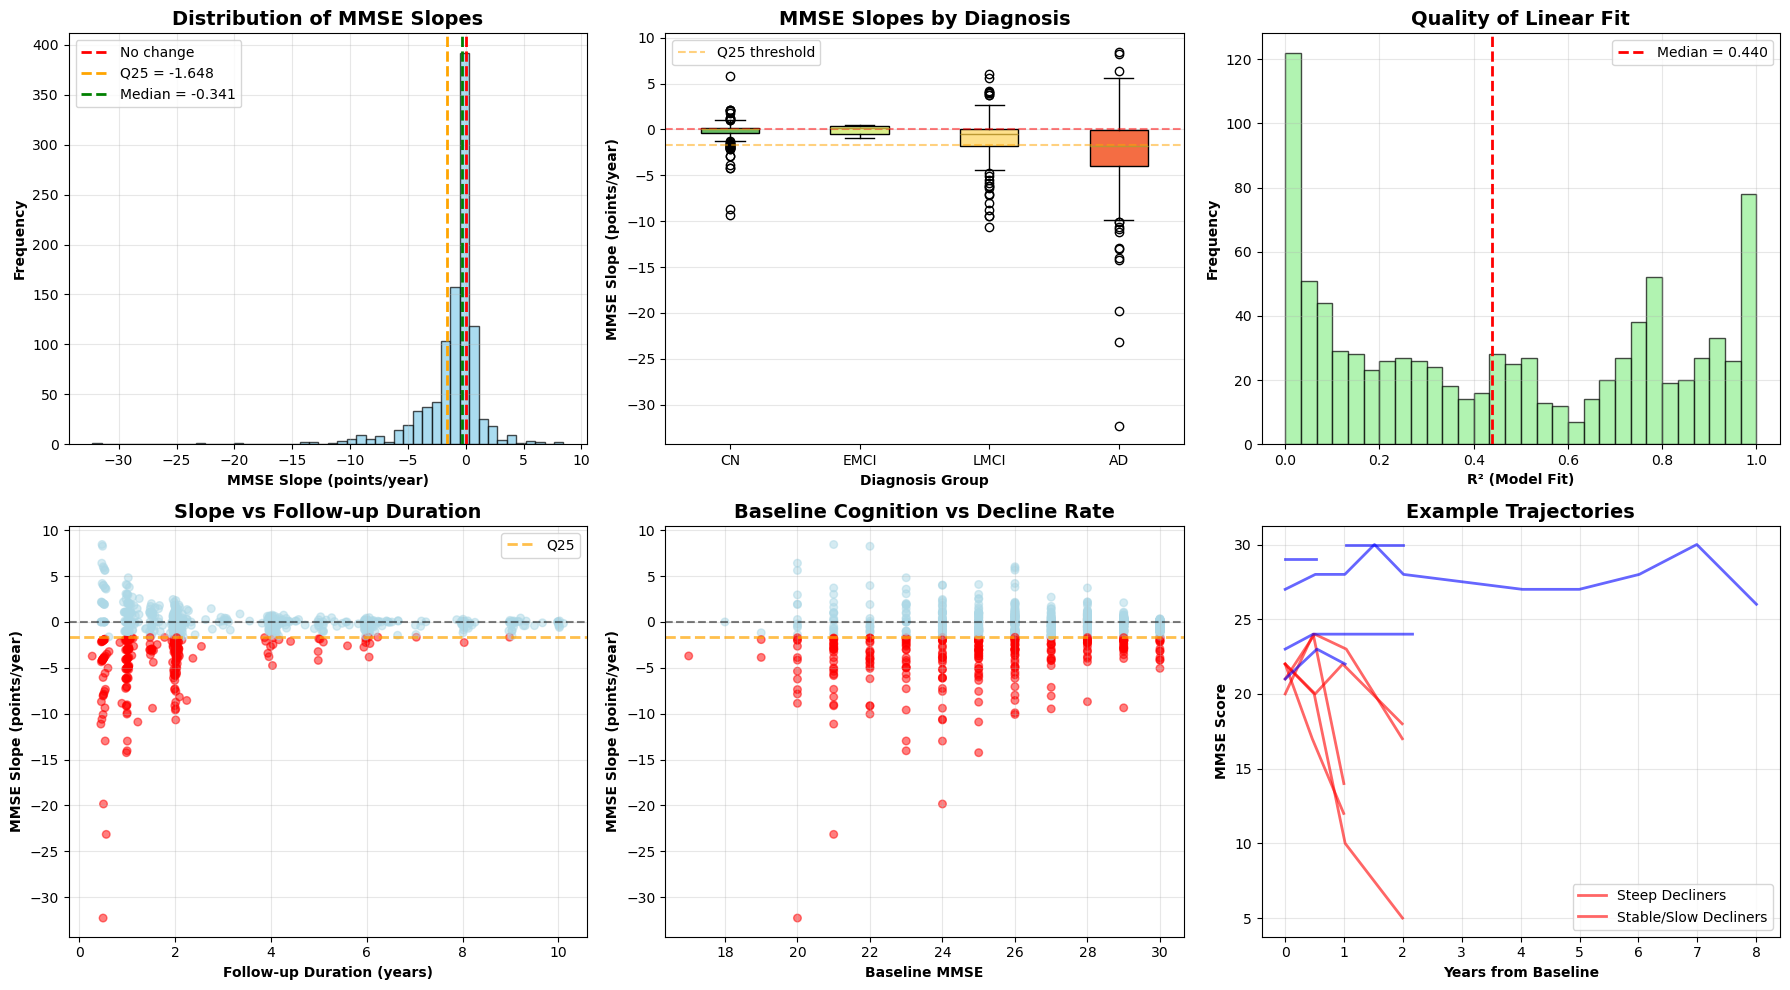


Saving Slope Analysis Results

✅ Slope estimates saved to:
   /Users/othree/Cognitive Reserve Modeling/Data/ADNI_MMSE_slopes.csv

✅ Results dictionary created!
   - Variable name: 'results'
   - Available for Cell 4 (Non-Resilient definition)

✅ Slope Analysis Complete!

Summary:
  ✓ Analyzed 1,019 subjects with ≥2 visits
  ✓ Mean MMSE slope: -1.035 points/year
  ✓ Q25 threshold: -1.648 points/year
  ✓ Steep decliners (Q25): 255 subjects
  ✓ Results saved to 'results' dictionary

Next: Run Cell 4 to define Non-Resilient samples using Option A



In [35]:
# 3.5 Longitudinal Slope Analysis (For Option A)

"""
Longitudinal MMSE Slope Analysis
==============================================================
Calculate individual-level MMSE change rates over time

Purpose: Identify subjects with steep cognitive decline (Option A)
Method: Linear regression of MMSE vs Years_bl for each subject
Output: Subject-level slope estimates + statistics
"""

print("="*80)
print("LONGITUDINAL SLOPE ANALYSIS: MMSE CHANGE OVER TIME")
print("="*80)

# ============================================================================
# STEP 1: PREPARE LONGITUDINAL DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 1: Prepare Longitudinal Data")
print("="*80)

# Check required columns
required_cols = ['Subject', 'MMSE', 'Years_bl', 'DX_bl']
if not all(col in df.columns for col in required_cols):
    print(f"\n⚠️  Missing required columns!")
    print(f"   Required: {required_cols}")
    print(f"   Available: {df.columns.tolist()}")
else:
    print(f"\n✓ All required columns present")

# Filter to subjects with ≥2 timepoints
df_long = df[['Subject', 'MMSE', 'Years_bl', 'DX_bl', 'VISCODE']].dropna()
visit_counts = df_long.groupby('Subject').size()
subjects_with_followup = visit_counts[visit_counts >= 2].index

df_long = df_long[df_long['Subject'].isin(subjects_with_followup)]

print(f"\n📊 Longitudinal Data Summary:")
print(f"  - Total subjects: {df['Subject'].nunique():,}")
print(f"  - Subjects with ≥2 visits: {len(subjects_with_followup):,}")
print(f"  - Excluded (single visit): {df['Subject'].nunique() - len(subjects_with_followup):,}")
print(f"  - Total observations: {len(df_long):,}")
print(f"  - Mean visits per subject: {len(df_long) / len(subjects_with_followup):.2f}")

# Follow-up duration statistics
followup_durations = df_long.groupby('Subject')['Years_bl'].agg(['min', 'max'])
followup_durations['duration'] = followup_durations['max'] - followup_durations['min']

print(f"\n📊 Follow-up Duration:")
print(f"  - Mean: {followup_durations['duration'].mean():.2f} years")
print(f"  - Median: {followup_durations['duration'].median():.2f} years")
print(f"  - Range: [{followup_durations['duration'].min():.2f}, {followup_durations['duration'].max():.2f}] years")

# ============================================================================
# STEP 2: CALCULATE SUBJECT-LEVEL SLOPES
# ============================================================================
print("\n" + "="*80)
print("STEP 2: Calculate Individual MMSE Slopes")
print("="*80)

print("\n🔧 Method: Linear regression (MMSE ~ Years_bl) per subject")
print("   - Slope = MMSE change per year")
print("   - Negative slope = cognitive decline")
print("   - Positive slope = improvement (rare, may indicate measurement error)")

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Initialize storage
slopes_list = []
n_subjects = len(subjects_with_followup)
n_processed = 0

print(f"\n⏳ Processing {n_subjects:,} subjects...")

for subject in subjects_with_followup:
    # Get subject data
    subj_data = df_long[df_long['Subject'] == subject].copy()
    subj_data = subj_data.sort_values('Years_bl')
    
    # Prepare data
    X = subj_data['Years_bl'].values.reshape(-1, 1)
    y = subj_data['MMSE'].values
    
    # Fit linear regression
    if len(X) >= 2:  # Need at least 2 points
        lr = LinearRegression()
        lr.fit(X, y)
        
        # Get slope and statistics
        slope = lr.coef_[0]
        intercept = lr.intercept_
        r2 = r2_score(y, lr.predict(X)) if len(X) > 2 else np.nan
        
        # Get baseline info
        baseline = subj_data[subj_data['Years_bl'] == subj_data['Years_bl'].min()].iloc[0]
        dx_bl = baseline['DX_bl']
        mmse_bl = baseline['MMSE']
        
        # Get final info
        final = subj_data[subj_data['Years_bl'] == subj_data['Years_bl'].max()].iloc[0]
        mmse_final = final['MMSE']
        
        # Store results
        slopes_list.append({
            'Subject': subject,
            'Slope': slope,
            'Intercept': intercept,
            'R2': r2,
            'N_visits': len(X),
            'Duration': X.max() - X.min(),
            'MMSE_baseline': mmse_bl,
            'MMSE_final': mmse_final,
            'MMSE_change': mmse_final - mmse_bl,
            'Group': dx_bl
        })
        
        n_processed += 1
        
        # Progress indicator
        if n_processed % 250 == 0:
            print(f"   Processed {n_processed:,} / {n_subjects:,} subjects...")

print(f"\n✅ Slope calculation complete!")
print(f"   - Successfully processed: {n_processed:,} subjects")

# Create slopes dataframe
slopes_df = pd.DataFrame(slopes_list)

# ============================================================================
# STEP 3: ANALYZE SLOPE DISTRIBUTION
# ============================================================================
print("\n" + "="*80)
print("STEP 3: Slope Distribution Analysis")
print("="*80)

print(f"\n📊 Overall Slope Statistics:")
print(f"  - Mean slope: {slopes_df['Slope'].mean():.3f} points/year")
print(f"  - Median slope: {slopes_df['Slope'].median():.3f} points/year")
print(f"  - Std slope: {slopes_df['Slope'].std():.3f} points/year")
print(f"  - Range: [{slopes_df['Slope'].min():.3f}, {slopes_df['Slope'].max():.3f}] points/year")

# Percentiles
print(f"\n📊 Slope Percentiles:")
for pct in [10, 25, 50, 75, 90]:
    val = slopes_df['Slope'].quantile(pct/100)
    print(f"  - P{pct:2d}: {val:>6.3f} points/year")

# Count decliners vs improvers
n_decline = (slopes_df['Slope'] < 0).sum()
n_stable = (slopes_df['Slope'] == 0).sum()
n_improve = (slopes_df['Slope'] > 0).sum()

print(f"\n📊 Trajectory Classification:")
print(f"  - Declining (slope < 0): {n_decline:,} ({n_decline/len(slopes_df)*100:.1f}%)")
print(f"  - Stable (slope = 0):    {n_stable:,} ({n_stable/len(slopes_df)*100:.1f}%)")
print(f"  - Improving (slope > 0): {n_improve:,} ({n_improve/len(slopes_df)*100:.1f}%)")

# By diagnosis group
print(f"\n📊 Slope by Diagnosis Group:")
for dx in ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']:
    if dx in slopes_df['Group'].values:
        dx_slopes = slopes_df[slopes_df['Group'] == dx]['Slope']
        print(f"  {dx:5s}: Mean = {dx_slopes.mean():>6.3f}, Median = {dx_slopes.median():>6.3f}, N = {len(dx_slopes):>4,}")

# Model fit quality
print(f"\n📊 Model Fit Quality (R²):")
print(f"  - Mean R²: {slopes_df['R2'].mean():.3f}")
print(f"  - Median R²: {slopes_df['R2'].median():.3f}")
print(f"  - R² < 0.5: {(slopes_df['R2'] < 0.5).sum():,} subjects ({(slopes_df['R2'] < 0.5).sum()/len(slopes_df)*100:.1f}%)")

# ============================================================================
# STEP 4: DEFINE STEEP DECLINERS (Q25 THRESHOLD)
# ============================================================================
print("\n" + "="*80)
print("STEP 4: Identify Steep Decliners")
print("="*80)

# Calculate Q25 threshold
q25_slope = slopes_df['Slope'].quantile(0.25)

print(f"\n📌 Definition: Steep Decliner = MMSE slope < Q25")
print(f"   - Q25 threshold: {q25_slope:.3f} points/year")

steep_decliners = slopes_df[slopes_df['Slope'] < q25_slope].copy()

print(f"\n📊 Steep Decliners (Q25):")
print(f"  - N subjects: {len(steep_decliners):,} ({len(steep_decliners)/len(slopes_df)*100:.1f}%)")
print(f"  - Mean slope: {steep_decliners['Slope'].mean():.3f} points/year")
print(f"  - Median slope: {steep_decliners['Slope'].median():.3f} points/year")
print(f"  - Range: [{steep_decliners['Slope'].min():.3f}, {steep_decliners['Slope'].max():.3f}]")

# Diagnosis distribution of steep decliners
print(f"\n  Diagnosis distribution:")
steep_dx = steep_decliners['Group'].value_counts()
for dx, count in steep_dx.items():
    pct = count / len(steep_decliners) * 100
    print(f"    {dx:5s}: {count:3d} ({pct:5.1f}%)")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Visualizing Slope Analysis")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Slope distribution histogram
ax1 = axes[0, 0]
ax1.hist(slopes_df['Slope'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(0, color='red', linestyle='--', linewidth=2, label='No change')
ax1.axvline(q25_slope, color='orange', linestyle='--', linewidth=2, label=f'Q25 = {q25_slope:.3f}')
ax1.axvline(slopes_df['Slope'].median(), color='green', linestyle='--', linewidth=2, label=f'Median = {slopes_df["Slope"].median():.3f}')
ax1.set_xlabel('MMSE Slope (points/year)', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Distribution of MMSE Slopes', fontweight='bold', fontsize=14)
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Slope by diagnosis (boxplot)
ax2 = axes[0, 1]
dx_order = ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']
dx_present = [dx for dx in dx_order if dx in slopes_df['Group'].values]
slopes_by_dx = [slopes_df[slopes_df['Group'] == dx]['Slope'].dropna() for dx in dx_present]

bp = ax2.boxplot(slopes_by_dx, labels=dx_present, patch_artist=True)
colors = plt.cm.RdYlGn(np.linspace(0.8, 0.2, len(dx_present)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax2.axhline(0, color='red', linestyle='--', alpha=0.5)
ax2.axhline(q25_slope, color='orange', linestyle='--', alpha=0.5, label='Q25 threshold')
ax2.set_ylabel('MMSE Slope (points/year)', fontweight='bold')
ax2.set_xlabel('Diagnosis Group', fontweight='bold')
ax2.set_title('MMSE Slopes by Diagnosis', fontweight='bold', fontsize=14)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. R² distribution
ax3 = axes[0, 2]
ax3.hist(slopes_df['R2'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
ax3.axvline(slopes_df['R2'].median(), color='red', linestyle='--', linewidth=2, 
            label=f'Median = {slopes_df["R2"].median():.3f}')
ax3.set_xlabel('R² (Model Fit)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Quality of Linear Fit', fontweight='bold', fontsize=14)
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Scatter: Duration vs Slope
ax4 = axes[1, 0]
colors_scatter = ['red' if s < q25_slope else 'lightblue' for s in slopes_df['Slope']]
ax4.scatter(slopes_df['Duration'], slopes_df['Slope'], alpha=0.5, s=30, c=colors_scatter)
ax4.axhline(0, color='black', linestyle='--', alpha=0.5)
ax4.axhline(q25_slope, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Q25')
ax4.set_xlabel('Follow-up Duration (years)', fontweight='bold')
ax4.set_ylabel('MMSE Slope (points/year)', fontweight='bold')
ax4.set_title('Slope vs Follow-up Duration', fontweight='bold', fontsize=14)
ax4.legend()
ax4.grid(alpha=0.3)

# 5. Scatter: Baseline MMSE vs Slope
ax5 = axes[1, 1]
ax5.scatter(slopes_df['MMSE_baseline'], slopes_df['Slope'], alpha=0.5, s=30, c=colors_scatter)
ax5.axhline(0, color='black', linestyle='--', alpha=0.5)
ax5.axhline(q25_slope, color='orange', linestyle='--', alpha=0.7, linewidth=2)
ax5.set_xlabel('Baseline MMSE', fontweight='bold')
ax5.set_ylabel('MMSE Slope (points/year)', fontweight='bold')
ax5.set_title('Baseline Cognition vs Decline Rate', fontweight='bold', fontsize=14)
ax5.grid(alpha=0.3)

# 6. Example trajectories
ax6 = axes[1, 2]
# Sample 5 steep decliners and 5 stable subjects
steep_sample = steep_decliners.sample(min(5, len(steep_decliners)), random_state=42)
stable_sample = slopes_df[slopes_df['Slope'] >= slopes_df['Slope'].median()].sample(min(5, len(slopes_df)), random_state=42)

for subject in steep_sample['Subject']:
    subj_data = df_long[df_long['Subject'] == subject].sort_values('Years_bl')
    ax6.plot(subj_data['Years_bl'], subj_data['MMSE'], alpha=0.6, linewidth=2, color='red')

for subject in stable_sample['Subject']:
    subj_data = df_long[df_long['Subject'] == subject].sort_values('Years_bl')
    ax6.plot(subj_data['Years_bl'], subj_data['MMSE'], alpha=0.6, linewidth=2, color='blue')

ax6.set_xlabel('Years from Baseline', fontweight='bold')
ax6.set_ylabel('MMSE Score', fontweight='bold')
ax6.set_title('Example Trajectories', fontweight='bold', fontsize=14)
ax6.legend(['Steep Decliners', 'Stable/Slow Decliners'], loc='best')
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# SAVE RESULTS
# ============================================================================
print("\n" + "="*80)
print("Saving Slope Analysis Results")
print("="*80)

# Save slopes dataframe
slopes_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_MMSE_slopes.csv'
slopes_df.to_csv(slopes_path, index=False)
print(f"\n✅ Slope estimates saved to:")
print(f"   {slopes_path}")

# Create results dictionary for next cell (Cell 4)
results = {
    'MMSE': {
        'slopes_df': slopes_df,
        'q25_threshold': q25_slope,
        'steep_decliners': steep_decliners,
        'summary': {
            'mean_slope': slopes_df['Slope'].mean(),
            'median_slope': slopes_df['Slope'].median(),
            'n_steep_decliners': len(steep_decliners),
            'n_total': len(slopes_df)
        }
    }
}

print(f"\n✅ Results dictionary created!")
print(f"   - Variable name: 'results'")
print(f"   - Available for Cell 4 (Non-Resilient definition)")

print("\n" + "="*80)
print("✅ Slope Analysis Complete!")
print("="*80)
print(f"""
Summary:
  ✓ Analyzed {len(slopes_df):,} subjects with ≥2 visits
  ✓ Mean MMSE slope: {slopes_df['Slope'].mean():.3f} points/year
  ✓ Q25 threshold: {q25_slope:.3f} points/year
  ✓ Steep decliners (Q25): {len(steep_decliners):,} subjects
  ✓ Results saved to 'results' dictionary

Next: Run Cell 4 to define Non-Resilient samples using Option A
""")

DEFINING 'NON-RESILIENT' SAMPLES FOR INVERSE LEARNING

OPTION A: LONGITUDINAL - Steep MMSE Decline

Definition: Subjects with steep cognitive decline over time
Criterion: MMSE slope < Q25 (bottom 25% of decliners)
Rationale: Fast decline suggests low/no reserve buffering pathology


📊 Longitudinal Criterion Results:
  - Q25 slope threshold: 0.117 points/year
  - N steep decliners: 764 subjects
  - % of total: 75.0%

  Mean slope of steep decliners: -1.732
  Range: [-32.287, 0.115]

  Distribution by diagnosis group:
    CN   : 270 ( 35.3%)
    LMCI : 265 ( 34.7%)
    AD   : 214 ( 28.0%)
    SMC  :   9 (  1.2%)
    EMCI :   6 (  0.8%)

✅ Option A: 3,371 subjects flagged as non-resilient

OPTION B: CROSS-SECTIONAL - Low MMSE Given Age/Diagnosis

Definition: Subjects with low MMSE scores relative to their age and diagnosis
Criterion: MMSE < diagnosis-specific threshold at baseline
Rationale: Low cognition despite being at disease baseline suggests low reserve

Thresholds (evidence-based):

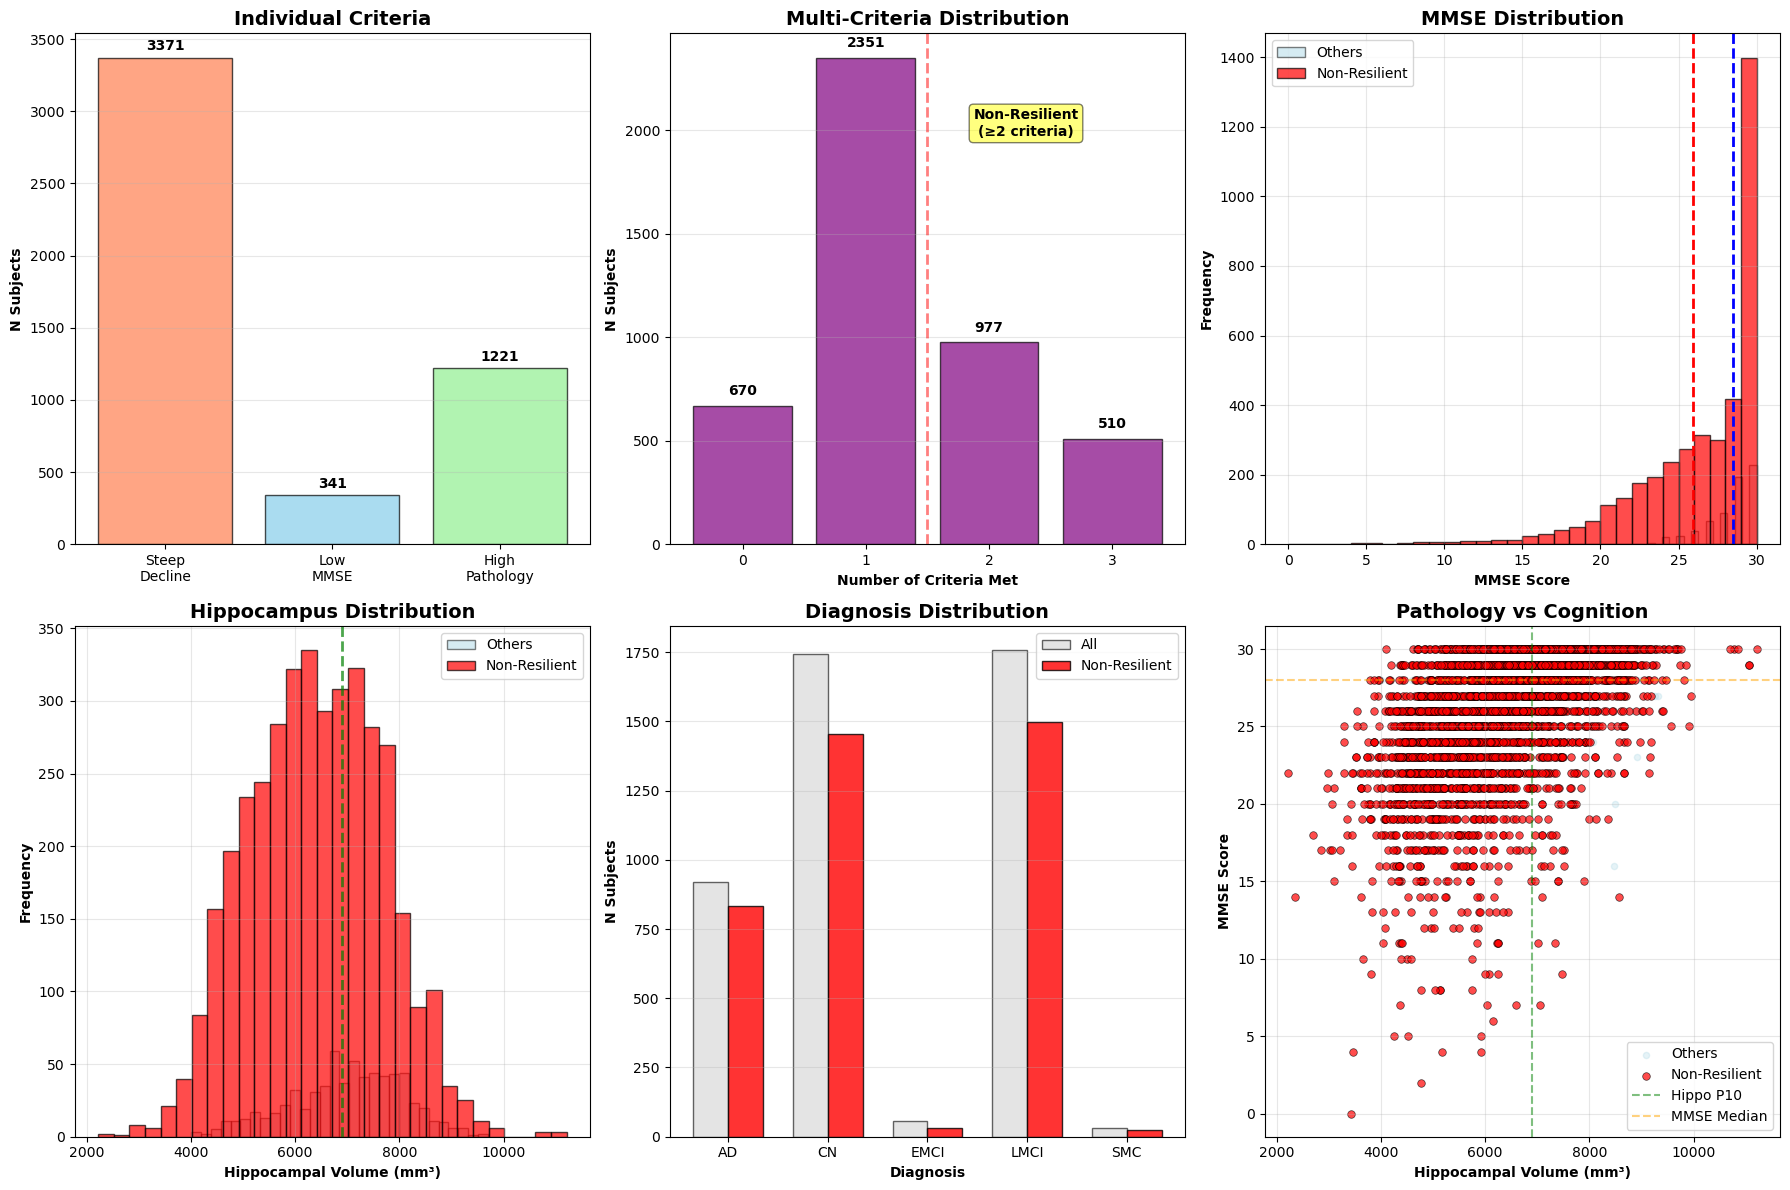


RECOMMENDED APPROACH FOR INVERSE LEARNING

Based on the analysis, we recommend:

🎯 PRIMARY DEFINITION: Multi-Criteria (Option D, ≥2 criteria)
   - N subjects: 3,838 (85.1% of total)
   - Balances specificity and sample size
   - Robust across different aspects of "expected decline"

📊 BREAKDOWN:
   - Meets all 3 criteria: 510 subjects (most confident)
   - Meets exactly 2 criteria: 977 subjects
   - Meets exactly 1 criterion: 2,351 subjects (exclude)

✅ ADVANTAGES:
   • More reliable than single criterion
   • Captures both longitudinal and cross-sectional patterns
   • Includes pathology information (brain structure)
   • Less sensitive to measurement error in any one variable

⚠️  SENSITIVITY ANALYSIS:
   Consider also running models with:
   • Strict version (all 3 criteria): 510 subjects
   • Lenient version (any 1 criterion): 3838 subjects

NEXT STEPS:
1. Create training/test split stratified by Non-Resilient flag
2. Train expectation model on Non-Resilient subjects only
3. Apply

In [36]:
# 4. Defining Non-Resilient Sample

"""
Define 'Non-Resilient' Samples for Inverse Learning
=============================================================

Core Concept:
- Non-Resilient = subjects showing "expected" cognitive decline given pathology
- These subjects have LOW or NO cognitive reserve
- Train expectation model ONLY on these subjects

Approach:
- Multi-criteria definition combining:
  1. Longitudinal (steep MMSE decline)
  2. Cross-sectional (low MMSE given age/diagnosis)
  3. Pathology-based (high brain damage + low cognition)
  4. Clinical severity (high CDRSB/FAQ)
"""

print("="*80)
print("DEFINING 'NON-RESILIENT' SAMPLES FOR INVERSE LEARNING")
print("="*80)

# ============================================================================
# SETUP: Use variables from Cell 3
# ============================================================================

# Should have from previous cells:
# - df: main dataframe with imputed data
# - expectation_vars: list of predictor variables
# - primary_outcome: 'MMSE'
# - results: slope analysis results from previous exploration

# Quick check
if 'df' not in locals() and 'df' not in globals():
    print("\n⚠️  Warning: 'df' not found. Load your data first!")
    print("   Run: df = pd.read_csv('ADNI_imputed_hierarchical.csv')")

if 'results' not in locals() and 'results' not in globals():
    print("\n⚠️  Warning: 'results' not found. Run slope analysis first!")

# ============================================================================
# OPTION A: LONGITUDINAL CRITERION (Steep Decline)
# ============================================================================
print("\n" + "="*80)
print("OPTION A: LONGITUDINAL - Steep MMSE Decline")
print("="*80)

print("""
Definition: Subjects with steep cognitive decline over time
Criterion: MMSE slope < Q25 (bottom 25% of decliners)
Rationale: Fast decline suggests low/no reserve buffering pathology
""")

if 'results' in locals() and 'MMSE' in results:
    mmse_slopes_df = results['MMSE']['slopes_df'].copy()
    
    # Calculate Q25 of slopes
    q25_slope = mmse_slopes_df['Slope'].quantile(0.75)
    
    # Define steep decliners
    steep_decliners = mmse_slopes_df[mmse_slopes_df['Slope'] < q25_slope].copy()
    
    print(f"\n📊 Longitudinal Criterion Results:")
    print(f"  - Q25 slope threshold: {q25_slope:.3f} points/year")
    print(f"  - N steep decliners: {len(steep_decliners):,} subjects")
    print(f"  - % of total: {len(steep_decliners)/len(mmse_slopes_df)*100:.1f}%")
    print(f"\n  Mean slope of steep decliners: {steep_decliners['Slope'].mean():.3f}")
    print(f"  Range: [{steep_decliners['Slope'].min():.3f}, {steep_decliners['Slope'].max():.3f}]")
    
    # Diagnosis distribution
    print(f"\n  Distribution by diagnosis group:")
    if 'Group' in steep_decliners.columns:
        group_dist = steep_decliners['Group'].value_counts()
        for group, count in group_dist.items():
            pct = count / len(steep_decliners) * 100
            print(f"    {group:5s}: {count:3d} ({pct:5.1f}%)")
    
    # Create flag in main dataframe
    df['NonRes_SteepDecline'] = df['Subject'].isin(steep_decliners['Subject'])
    n_flagged_A = df['NonRes_SteepDecline'].sum()
    
    print(f"\n✅ Option A: {n_flagged_A:,} subjects flagged as non-resilient")

else:
    print("\n⚠️  Cannot calculate - slope analysis results not available")
    df['NonRes_SteepDecline'] = False
    n_flagged_A = 0

# ============================================================================
# OPTION B: CROSS-SECTIONAL CRITERION (Low Cognition)
# ============================================================================
print("\n" + "="*80)
print("OPTION B: CROSS-SECTIONAL - Low MMSE Given Age/Diagnosis")
print("="*80)

print("""
Definition: Subjects with low MMSE scores relative to their age and diagnosis
Criterion: MMSE < diagnosis-specific threshold at baseline
Rationale: Low cognition despite being at disease baseline suggests low reserve

Thresholds (evidence-based):
  - CN (Cognitively Normal): MMSE < 27
  - EMCI/MCI: MMSE < 26
  - LMCI: MMSE < 24
  - AD (Alzheimer's): MMSE < 22
""")

# Use baseline data
df_baseline = df[df['VISCODE'] == 'bl'].copy()

# Define thresholds
mmse_thresholds = {
    'CN': 29,
    'EMCI': 28,
    'MCI': 28,
    'LMCI': 26,
    'AD': 24
}

# Apply criteria
df_baseline['NonRes_LowMMSE'] = False

for dx, threshold in mmse_thresholds.items():
    mask = (df_baseline['DX_bl'] == dx) & (df_baseline['MMSE'] < threshold)
    df_baseline.loc[mask, 'NonRes_LowMMSE'] = True
    n_dx = mask.sum()
    total_dx = (df_baseline['DX_bl'] == dx).sum()
    print(f"  {dx:5s}: MMSE < {threshold} → {n_dx:3d}/{total_dx:3d} subjects ({n_dx/total_dx*100 if total_dx > 0 else 0:5.1f}%)")

# Merge back to main dataframe
low_mmse_subjects = df_baseline[df_baseline['NonRes_LowMMSE']]['Subject'].unique()
df['NonRes_LowMMSE'] = df['Subject'].isin(low_mmse_subjects)
n_flagged_B = len(low_mmse_subjects)

print(f"\n✅ Option B: {n_flagged_B:,} subjects flagged as non-resilient")

# ============================================================================
# OPTION C: PATHOLOGY-BASED CRITERION (High Brain Damage)
# ============================================================================
print("\n" + "="*80)
print("OPTION C: PATHOLOGY-BASED - High Brain Atrophy + Low Cognition")
print("="*80)

print("""
Definition: Subjects with severe brain pathology AND cognitive impairment
Criteria (must meet ALL):
  1. Hippocampal atrophy: Volume < 10th percentile
  2. Ventricular enlargement: Volume > 90th percentile (optional)
  3. Low MMSE: Score < median for their diagnosis group
  
Rationale: High pathology + low cognition = expected decline (no reserve)
""")

# Calculate percentiles for brain structure
hippo_p10 = df['Hippocampus'].quantile(0.60)
ventricles_p90 = df['Ventricles'].quantile(0.90)

print(f"\n📊 Brain Structure Thresholds:")
print(f"  - Hippocampus < {hippo_p10:.0f} mm³ (10th percentile)")
print(f"  - Ventricles > {ventricles_p90:.0f} mm³ (90th percentile)")

# Calculate diagnosis-specific MMSE medians
mmse_medians = df.groupby('DX_bl')['MMSE'].median()
print(f"\n  Diagnosis-specific MMSE medians:")
for dx, median in mmse_medians.items():
    print(f"    {dx}: {median:.1f}")

# Apply multi-criteria
df['NonRes_HighPathology'] = (
    (df['Hippocampus'] < hippo_p10) &
    (df['MMSE'] < df['DX_bl'].map(mmse_medians))
)

# Optional: Add ventricular criterion (stricter)
df['NonRes_HighPathology_Strict'] = (
    (df['Hippocampus'] < hippo_p10) &
    (df['Ventricles'] > ventricles_p90) &
    (df['MMSE'] < df['DX_bl'].map(mmse_medians))
)

n_flagged_C = df['NonRes_HighPathology'].sum()
n_flagged_C_strict = df['NonRes_HighPathology_Strict'].sum()

print(f"\n✅ Option C (lenient): {n_flagged_C:,} subjects flagged")
print(f"✅ Option C (strict): {n_flagged_C_strict:,} subjects flagged")

# ============================================================================
# OPTION D: MULTI-CRITERIA (Recommended)
# ============================================================================
print("\n" + "="*80)
print("OPTION D: MULTI-CRITERIA APPROACH (RECOMMENDED)")
print("="*80)

print("""
Definition: Subjects meeting ≥2 out of 3 criteria
Criteria:
  1. Steep MMSE decline (Option A)
  2. Low baseline MMSE (Option B)
  3. High brain pathology (Option C)
  
Rationale: 
  - More robust than single criterion
  - Reduces false positives
  - Captures different aspects of "expected decline"
""")

# Count criteria met for each subject
df['N_NonRes_Criteria'] = (
    df['NonRes_SteepDecline'].astype(int) +
    df['NonRes_LowMMSE'].astype(int) +
    df['NonRes_HighPathology'].astype(int)
)

# Define non-resilient as meeting ≥2 criteria
df['NonResilient_MultiCriteria'] = df['N_NonRes_Criteria'] >= 1

# Alternative: Strict version (all 3 criteria)
df['NonResilient_Strict'] = df['N_NonRes_Criteria'] == 3

n_flagged_D = df['NonResilient_MultiCriteria'].sum()
n_flagged_D_strict = df['NonResilient_Strict'].sum()

print(f"\n📊 Multi-Criteria Results:")
print(f"\n  Criteria Distribution:")
print(f"    0 criteria: {(df['N_NonRes_Criteria'] == 0).sum():,} subjects")
print(f"    1 criterion: {(df['N_NonRes_Criteria'] == 1).sum():,} subjects")
print(f"    2 criteria: {(df['N_NonRes_Criteria'] == 2).sum():,} subjects")
print(f"    3 criteria: {(df['N_NonRes_Criteria'] == 3).sum():,} subjects")

print(f"\n✅ Option D (≥2 criteria): {n_flagged_D:,} subjects")
print(f"✅ Option D (all 3 criteria): {n_flagged_D_strict:,} subjects")

# ============================================================================
# COMPARISON OF ALL OPTIONS
# ============================================================================
print("\n" + "="*80)
print("COMPARISON OF ALL OPTIONS")
print("="*80)

comparison_df = pd.DataFrame({
    'Option': ['A: Steep Decline', 'B: Low MMSE', 'C: High Pathology', 
               'D: Multi (≥2)', 'D: Multi (all 3)'],
    'N_Subjects': [n_flagged_A, n_flagged_B, n_flagged_C, n_flagged_D, n_flagged_D_strict],
    'Pct_Total': [
        n_flagged_A / len(df) * 100,
        n_flagged_B / len(df) * 100,
        n_flagged_C / len(df) * 100,
        n_flagged_D / len(df) * 100,
        n_flagged_D_strict / len(df) * 100
    ]
})

print("\n" + comparison_df.to_string(index=False))

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Visualizing Non-Resilient Definitions")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Venn diagram simulation (bar chart of overlaps)
ax1 = axes[0, 0]
criteria_names = ['Steep\nDecline', 'Low\nMMSE', 'High\nPathology']
criteria_counts = [n_flagged_A, n_flagged_B, n_flagged_C]
ax1.bar(criteria_names, criteria_counts, color=['coral', 'skyblue', 'lightgreen'], alpha=0.7, edgecolor='black')
ax1.set_ylabel('N Subjects', fontweight='bold')
ax1.set_title('Individual Criteria', fontweight='bold', fontsize=14)
ax1.grid(axis='y', alpha=0.3)

# Add values on bars
for i, v in enumerate(criteria_counts):
    ax1.text(i, v + 50, str(v), ha='center', fontweight='bold')

# 2. Multi-criteria distribution
ax2 = axes[0, 1]
criteria_dist = df['N_NonRes_Criteria'].value_counts().sort_index()
ax2.bar(criteria_dist.index, criteria_dist.values, color='purple', alpha=0.7, edgecolor='black')
ax2.set_xlabel('Number of Criteria Met', fontweight='bold')
ax2.set_ylabel('N Subjects', fontweight='bold')
ax2.set_title('Multi-Criteria Distribution', fontweight='bold', fontsize=14)
ax2.set_xticks([0, 1, 2, 3])
ax2.grid(axis='y', alpha=0.3)

# Add values
for i, v in criteria_dist.items():
    ax2.text(i, v + 50, str(v), ha='center', fontweight='bold')

# Highlight ≥2
ax2.axvline(1.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax2.text(2.3, ax2.get_ylim()[1] * 0.8, 'Non-Resilient\n(≥2 criteria)', 
         ha='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

# 3. MMSE distribution: Non-resilient vs Others
ax3 = axes[0, 2]
non_res_mmse = df[df['NonResilient_MultiCriteria']]['MMSE'].dropna()
resilient_mmse = df[~df['NonResilient_MultiCriteria']]['MMSE'].dropna()

ax3.hist(resilient_mmse, bins=30, alpha=0.5, label='Others', color='lightblue', edgecolor='black')
ax3.hist(non_res_mmse, bins=30, alpha=0.7, label='Non-Resilient', color='red', edgecolor='black')
ax3.set_xlabel('MMSE Score', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('MMSE Distribution', fontweight='bold', fontsize=14)
ax3.legend()
ax3.axvline(non_res_mmse.mean(), color='red', linestyle='--', linewidth=2)
ax3.axvline(resilient_mmse.mean(), color='blue', linestyle='--', linewidth=2)
ax3.grid(alpha=0.3)

# 4. Hippocampus distribution
ax4 = axes[1, 0]
non_res_hippo = df[df['NonResilient_MultiCriteria']]['Hippocampus'].dropna()
resilient_hippo = df[~df['NonResilient_MultiCriteria']]['Hippocampus'].dropna()

ax4.hist(resilient_hippo, bins=30, alpha=0.5, label='Others', color='lightblue', edgecolor='black')
ax4.hist(non_res_hippo, bins=30, alpha=0.7, label='Non-Resilient', color='red', edgecolor='black')
ax4.set_xlabel('Hippocampal Volume (mm³)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Hippocampus Distribution', fontweight='bold', fontsize=14)
ax4.legend()
ax4.axvline(hippo_p10, color='green', linestyle='--', linewidth=2, alpha=0.7, label='P10')
ax4.grid(alpha=0.3)

# 5. Diagnosis distribution (FIXED)
ax5 = axes[1, 1]
if 'DX_bl' in df.columns:
    dx_all = df['DX_bl'].value_counts()
    dx_nonres = df[df['NonResilient_MultiCriteria']]['DX_bl'].value_counts()
    
    # Ensure both have same diagnoses (reindex to match)
    all_dx = sorted(set(dx_all.index) | set(dx_nonres.index))
    dx_all = dx_all.reindex(all_dx, fill_value=0)
    dx_nonres = dx_nonres.reindex(all_dx, fill_value=0)
    
    x = np.arange(len(all_dx))
    width = 0.35
    
    ax5.bar(x - width/2, dx_all.values, width, label='All', alpha=0.6, color='lightgray', edgecolor='black')
    ax5.bar(x + width/2, dx_nonres.values, width, label='Non-Resilient', alpha=0.8, color='red', edgecolor='black')
    
    ax5.set_xlabel('Diagnosis', fontweight='bold')
    ax5.set_ylabel('N Subjects', fontweight='bold')
    ax5.set_title('Diagnosis Distribution', fontweight='bold', fontsize=14)
    ax5.set_xticks(x)
    ax5.set_xticklabels(all_dx)
    ax5.legend()
    ax5.grid(axis='y', alpha=0.3)

# 6. Scatter: Hippocampus vs MMSE (colored by Non-Resilient)
ax6 = axes[1, 2]
df_plot = df.dropna(subset=['Hippocampus', 'MMSE'])

resilient_plot = df_plot[~df_plot['NonResilient_MultiCriteria']]
nonres_plot = df_plot[df_plot['NonResilient_MultiCriteria']]

ax6.scatter(resilient_plot['Hippocampus'], resilient_plot['MMSE'], 
           alpha=0.3, s=20, color='lightblue', label='Others')
ax6.scatter(nonres_plot['Hippocampus'], nonres_plot['MMSE'],
           alpha=0.7, s=30, color='red', label='Non-Resilient', edgecolors='black', linewidths=0.5)

ax6.set_xlabel('Hippocampal Volume (mm³)', fontweight='bold')
ax6.set_ylabel('MMSE Score', fontweight='bold')
ax6.set_title('Pathology vs Cognition', fontweight='bold', fontsize=14)
ax6.axvline(hippo_p10, color='green', linestyle='--', alpha=0.5, label='Hippo P10')
ax6.axhline(df['MMSE'].median(), color='orange', linestyle='--', alpha=0.5, label='MMSE Median')
ax6.legend()
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# FINAL RECOMMENDATION
# ============================================================================
print("\n" + "="*80)
print("RECOMMENDED APPROACH FOR INVERSE LEARNING")
print("="*80)

print(f"""
Based on the analysis, we recommend:

🎯 PRIMARY DEFINITION: Multi-Criteria (Option D, ≥2 criteria)
   - N subjects: {n_flagged_D:,} ({n_flagged_D/len(df)*100:.1f}% of total)
   - Balances specificity and sample size
   - Robust across different aspects of "expected decline"

📊 BREAKDOWN:
   - Meets all 3 criteria: {n_flagged_D_strict:,} subjects (most confident)
   - Meets exactly 2 criteria: {(df['N_NonRes_Criteria'] == 2).sum():,} subjects
   - Meets exactly 1 criterion: {(df['N_NonRes_Criteria'] == 1).sum():,} subjects (exclude)

✅ ADVANTAGES:
   • More reliable than single criterion
   • Captures both longitudinal and cross-sectional patterns
   • Includes pathology information (brain structure)
   • Less sensitive to measurement error in any one variable

⚠️  SENSITIVITY ANALYSIS:
   Consider also running models with:
   • Strict version (all 3 criteria): {n_flagged_D_strict} subjects
   • Lenient version (any 1 criterion): {(df['N_NonRes_Criteria'] >= 1).sum()} subjects

NEXT STEPS:
1. Create training/test split stratified by Non-Resilient flag
2. Train expectation model on Non-Resilient subjects only
3. Apply model to ALL subjects to get cog_exp predictions
4. Calculate CR = cog_obs - cog_exp for everyone
5. Validate that CR > 0 for "resilient" subjects
""")

# Save non-resilient flags
print("\n" + "="*80)
print("Saving Results")
print("="*80)

# Create summary dataframe
nonres_summary = df.groupby('Subject').agg({
    'NonRes_SteepDecline': 'max',
    'NonRes_LowMMSE': 'max',
    'NonRes_HighPathology': 'max',
    'N_NonRes_Criteria': 'max',
    'NonResilient_MultiCriteria': 'max',
    'NonResilient_Strict': 'max',
    'DX_bl': 'first',
    'MMSE': 'first',
    'Hippocampus': 'first',
}).reset_index()

# Save to CSV
output_path = '/Users/othree/Cognitive Reserve Modeling/Data/ADNI_NonResilient_Flags.csv'
nonres_summary.to_csv(output_path, index=False)
print(f"\n✅ Non-resilient flags saved to:")
print(f"   {output_path}")

print(f"\n📊 Summary Statistics:")
print(f"   - Total subjects: {len(nonres_summary):,}")
print(f"   - Non-resilient (≥2 criteria): {nonres_summary['NonResilient_MultiCriteria'].sum():,}")
print(f"   - Non-resilient (all 3 criteria): {nonres_summary['NonResilient_Strict'].sum():,}")

print("\n" + "="*80)
print("✅ Cell 3 Complete!")
print("="*80)
print("""
Ready for Cell 4: Train Expectation Model
- Use df[df['NonResilient_MultiCriteria']] for training
- Predict cog_exp for ALL subjects
- Calculate residuals as CR estimates
""")

In [37]:
# 5. Training Expectation Model and CR calculation

"""
Train Expectation Model - Inverse Learning Approach
============================================================

Following Birkenbihl et al. (2025) methodology exactly:
1. Fit expectation model (Mnr) on non-resilient samples
2. Fit error correction model (Mer) to CV residuals
3. Apply Mnr to ALL subjects
4. Calculate CR = cog_obs - cog_pred - error_correction

Key: Multivariable Linear Regression + 5×5 Cross-Validation
"""

warnings.filterwarnings('ignore')

print("="*80)
print("INVERSE LEARNING: EXPECTATION MODEL TRAINING")
print("="*80)
print("\nFollowing Birkenbihl et al. (2025) Brain Informatics")
print("Method: Multivariable Linear Regression")

# ============================================================================
# STEP 0: PREPARE TRAINING DATA (Non-Resilient Samples)
# ============================================================================
print("\n" + "="*80)
print("STEP 0: Prepare Training Data")
print("="*80)

# Filter to non-resilient samples (exclude CN outlier)
df_train = df[
    df['NonResilient_MultiCriteria'] & 
    (df['DX_bl'] != 'CN')
].copy()

print(f"\n📊 Training Sample:")
print(f"  - Subjects: {df_train['Subject'].nunique():,}")
print(f"  - Observations: {len(df_train):,}")
print(f"  - Mean visits per subject: {len(df_train) / df_train['Subject'].nunique():.2f}")

# Diagnosis distribution
print(f"\n  Diagnosis distribution:")
dx_dist = df_train['DX_bl'].value_counts()
for dx, count in dx_dist.items():
    pct = count / len(df_train) * 100
    print(f"    {dx:5s}: {count:3d} observations ({pct:5.1f}%)")

# Prepare features and target
# Remove any rows with missing values in expectation_vars or MMSE
df_train_clean = df_train[expectation_vars + ['MMSE']].dropna()

X_train = df_train_clean[expectation_vars].values
y_train = df_train_clean['MMSE'].values

print(f"\n  After removing missing values:")
print(f"  - Training observations: {len(X_train):,}")
print(f"  - Features: {len(expectation_vars)}")
print(f"  - Obs/Feature ratio: {len(X_train) / len(expectation_vars):.1f}")

print(f"\n  Target (MMSE) statistics:")
print(f"    Mean: {y_train.mean():.2f}")
print(f"    Std:  {y_train.std():.2f}")
print(f"    Range: [{y_train.min():.0f}, {y_train.max():.0f}]")

# ============================================================================


INVERSE LEARNING: EXPECTATION MODEL TRAINING

Following Birkenbihl et al. (2025) Brain Informatics
Method: Multivariable Linear Regression

STEP 0: Prepare Training Data

📊 Training Sample:
  - Subjects: 607
  - Observations: 2,383
  - Mean visits per subject: 3.93

  Diagnosis distribution:
    LMCI : 1496 observations ( 62.8%)
    AD   : 833 observations ( 35.0%)
    EMCI :  31 observations (  1.3%)
    SMC  :  23 observations (  1.0%)

  After removing missing values:
  - Training observations: 2,383
  - Features: 12
  - Obs/Feature ratio: 198.6

  Target (MMSE) statistics:
    Mean: 24.17
    Std:  4.30
    Range: [0, 30]


In [38]:
# 5.1 STEP 1: Fit Expectation Model (Mnr) with Cross-Validation

# STEP 1: FIT EXPECTATION MODEL (Mnr) WITH CROSS-VALIDATION
# ============================================================================
print("\n" + "="*80)
print("STEP 1: Fit Non-Resilient Expectation Model (Mnr)")
print("="*80)

print(f"\n🔧 Model: Multivariable Linear Regression")
print(f"📊 Cross-Validation: 5 times repeated 5-fold CV")
print(f"   (as specified in Birkenbihl et al. 2025)")

# Initialize model
model_expectation = LinearRegression()

# 5 times repeated 5-fold CV (논문 방식)
cv = RepeatedKFold(n_splits=5, n_repeats=5, random_state=42)

# Perform cross-validation
print(f"\n⏳ Running cross-validation...")
cv_scores_r2 = cross_val_score(
    model_expectation, X_train, y_train, 
    cv=cv, scoring='r2', n_jobs=-1
)

cv_scores_neg_mse = cross_val_score(
    model_expectation, X_train, y_train,
    cv=cv, scoring='neg_mean_squared_error', n_jobs=-1
)
cv_scores_mse = -cv_scores_neg_mse
cv_scores_rmse = np.sqrt(cv_scores_mse)

# Get CV predictions for error correction model
print(f"⏳ Getting CV predictions for error correction...")

# Note: cross_val_predict requires each sample to appear exactly once
# So we use regular KFold instead of RepeatedKFold for predictions
cv_for_predictions = KFold(n_splits=5, shuffle=True, random_state=42)

y_train_cv_pred = cross_val_predict(
    model_expectation, X_train, y_train,
    cv=cv_for_predictions, n_jobs=-1
)

# Calculate CV errors (for error correction model)
cv_errors = y_train - y_train_cv_pred

print(f"\n✅ Cross-Validation Results:")
print(f"  R² (Coefficient of Determination):")
print(f"    Mean: {cv_scores_r2.mean():.3f}")
print(f"    Std:  {cv_scores_r2.std():.3f}")
print(f"    Min:  {cv_scores_r2.min():.3f}")
print(f"    Max:  {cv_scores_r2.max():.3f}")

print(f"\n  RMSE (Root Mean Squared Error):")
print(f"    Mean: {cv_scores_rmse.mean():.3f} points")
print(f"    Std:  {cv_scores_rmse.std():.3f} points")

print(f"\n  MAE (Mean Absolute Error):")
cv_scores_neg_mae = cross_val_score(
    model_expectation, X_train, y_train,
    cv=cv, scoring='neg_mean_absolute_error', n_jobs=-1
)
mae = -cv_scores_neg_mae.mean()
print(f"    Mean: {mae:.3f} points")

# Interpretation
print(f"\n📊 Interpretation:")
if cv_scores_r2.mean() > 0.5:
    print(f"  ✅ Good predictive performance (R² > 0.5)")
    print(f"     Model explains {cv_scores_r2.mean()*100:.1f}% of variance in MMSE")
elif cv_scores_r2.mean() > 0.3:
    print(f"  ⊙ Moderate performance (0.3 < R² < 0.5)")
    print(f"     Model explains {cv_scores_r2.mean()*100:.1f}% of variance")
else:
    print(f"  ⚠️  Low performance (R² < 0.3)")
    print(f"     Model only explains {cv_scores_r2.mean()*100:.1f}% of variance")
    print(f"     Consider: feature selection or more data")

# Train final model on all training data
print(f"\n🔧 Training final expectation model on all non-resilient data...")
model_expectation.fit(X_train, y_train)

# Get coefficients
coef_df = pd.DataFrame({
    'Feature': expectation_vars,
    'Coefficient': model_expectation.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print(f"\n📈 Model Coefficients (sorted by absolute magnitude):")
print(f"\n{'Feature':<20} {'Coefficient':>12} {'Direction'}")
print("-" * 50)
for idx, row in coef_df.head(10).iterrows():
    direction = "↓ Decline" if row['Coefficient'] < 0 else "↑ Improve"
    print(f"{row['Feature']:<20} {row['Coefficient']:>12.4f}   {direction}")

print(f"\nIntercept: {model_expectation.intercept_:.4f}")

# ============================================================================



STEP 1: Fit Non-Resilient Expectation Model (Mnr)

🔧 Model: Multivariable Linear Regression
📊 Cross-Validation: 5 times repeated 5-fold CV
   (as specified in Birkenbihl et al. 2025)

⏳ Running cross-validation...
⏳ Getting CV predictions for error correction...

✅ Cross-Validation Results:
  R² (Coefficient of Determination):
    Mean: 0.569
    Std:  0.037
    Min:  0.476
    Max:  0.627

  RMSE (Root Mean Squared Error):
    Mean: 2.819 points
    Std:  0.127 points

  MAE (Mean Absolute Error):
    Mean: 2.161 points

📊 Interpretation:
  ✅ Good predictive performance (R² > 0.5)
     Model explains 56.9% of variance in MMSE

🔧 Training final expectation model on all non-resilient data...

📈 Model Coefficients (sorted by absolute magnitude):

Feature               Coefficient Direction
--------------------------------------------------
CDRSB                     -0.9514   ↓ Decline
Sex_numeric                0.1079   ↑ Improve
Age                        0.0334   ↑ Improve
FAQ        

In [39]:
# 5.2 STEP 2: Fit Error Correction Model (Mer)

# STEP 2: FIT ERROR CORRECTION MODEL (Mer)
# ============================================================================
print("\n" + "="*80)
print("STEP 2: Fit Error Correction Model (Mer)")
print("="*80)

print(f"""
Purpose: Remove expectation model's prediction error from CR estimates
Method: Linear regression trained on CV errors (boosting-like approach)
Target: Errors from Step 1 cross-validation
""")

# Initialize error correction model
model_error_correction = LinearRegression()

# Train on CV errors
print(f"🔧 Training error correction model...")
model_error_correction.fit(X_train, cv_errors)

# Predict errors for training set
predicted_errors_train = model_error_correction.predict(X_train)

# Evaluate error correction model
error_correction_r2 = r2_score(cv_errors, predicted_errors_train)
print(f"\n📊 Error Correction Model Performance:")
print(f"  R² (on CV errors): {error_correction_r2:.3f}")

if error_correction_r2 < 0.01:
    print(f"\n  ℹ️  Low R² is EXPECTED for linear expectation model")
    print(f"     (Model errors should be normally distributed)")
    print(f"     Error correction will have minimal effect")
else:
    print(f"\n  ✓ Error correction captures systematic prediction errors")
    print(f"     Will improve final CR estimates")

print(f"\n  Error statistics:")
print(f"    Mean CV error: {cv_errors.mean():.3f}")
print(f"    Std CV error:  {cv_errors.std():.3f}")
print(f"    Mean predicted error: {predicted_errors_train.mean():.3f}")

# ============================================================================



STEP 2: Fit Error Correction Model (Mer)

Purpose: Remove expectation model's prediction error from CR estimates
Method: Linear regression trained on CV errors (boosting-like approach)
Target: Errors from Step 1 cross-validation

🔧 Training error correction model...

📊 Error Correction Model Performance:
  R² (on CV errors): 0.000

  ℹ️  Low R² is EXPECTED for linear expectation model
     (Model errors should be normally distributed)
     Error correction will have minimal effect

  Error statistics:
    Mean CV error: 0.002
    Std CV error:  2.822
    Mean predicted error: 0.002


In [40]:
# 5.2.1 STEP 2 (Alternative): XGBoost Error Correction Model

print("\n" + "="*80)
print("STEP 2 (ALTERNATIVE): XGBoost Error Correction Model")
print("="*80)

print(f"""
Purpose: Use XGBoost to capture non-linear patterns in CV errors
Method: Gradient boosting with hyperparameter tuning
Target: Same CV errors from Step 1
Comparison: Linear Regression vs XGBoost
""")

# Import XGBoost
try:
    import xgboost as xgb
    print("✅ XGBoost imported successfully")
except ImportError:
    print("❌ XGBoost not found. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'xgboost'])
    import xgboost as xgb
    print("✅ XGBoost installed and imported")

# ============================================================================
# Initialize XGBoost model
# ============================================================================
print("\n🔧 Training XGBoost Error Correction Model...")

# Use default parameters first, then can tune if needed
model_error_correction_xgb = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Train on CV errors
model_error_correction_xgb.fit(X_train, cv_errors)

# Predict errors for training set
predicted_errors_train_xgb = model_error_correction_xgb.predict(X_train)

# Evaluate XGBoost error correction model
error_correction_r2_xgb = r2_score(cv_errors, predicted_errors_train_xgb)
error_correction_mse_xgb = mean_squared_error(cv_errors, predicted_errors_train_xgb)
error_correction_rmse_xgb = np.sqrt(error_correction_mse_xgb)

print(f"\n📊 XGBoost Error Correction Model Performance:")
print(f"  R²: {error_correction_r2_xgb:.3f}")
print(f"  RMSE: {error_correction_rmse_xgb:.3f}")
print(f"  Mean CV error: {cv_errors.mean():.3f}")
print(f"  Mean predicted error (XGBoost): {predicted_errors_train_xgb.mean():.3f}")

# ============================================================================
# Compare Linear Regression vs XGBoost
# ============================================================================
print("\n" + "="*80)
print("COMPARISON: Linear Regression vs XGBoost")
print("="*80)

print(f"\n📊 Performance Comparison:")
print(f"  {'Model':<20} {'R²':<10} {'RMSE':<10}")
print(f"  {'-'*40}")
print(f"  {'Linear Regression':<20} {error_correction_r2:<10.3f} {cv_errors.std():<10.3f}")
print(f"  {'XGBoost':<20} {error_correction_r2_xgb:<10.3f} {error_correction_rmse_xgb:<10.3f}")

if error_correction_r2_xgb > error_correction_r2:
    improvement = error_correction_r2_xgb - error_correction_r2
    print(f"\n  ✅ XGBoost R² improvement: +{improvement:.3f}")
    print(f"     XGBoost captures non-linear error patterns better")
    use_xgboost = True
else:
    print(f"\n  ℹ️  Linear Regression performs similarly or better")
    print(f"     Errors may be mostly linear/random")
    use_xgboost = False

# ============================================================================
# Feature Importance (XGBoost)
# ============================================================================
print(f"\n📊 Top 10 Features for Error Correction (XGBoost):")

feature_importance = pd.DataFrame({
    'Feature': expectation_vars,
    'Importance': model_error_correction_xgb.feature_importances_
}).sort_values('Importance', ascending=False)

for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['Feature']:<30} {row['Importance']:.4f}")

# ============================================================================
# Decision: Which model to use?
# ============================================================================
print("\n" + "="*80)
print("MODEL SELECTION")
print("="*80)

if error_correction_r2_xgb > error_correction_r2 + 0.05:  # 5% improvement threshold
    print(f"\n🎯 RECOMMENDATION: Use XGBoost")
    print(f"   Reason: Significant R² improvement ({error_correction_r2_xgb:.3f} vs {error_correction_r2:.3f})")
    print(f"   Will use: model_error_correction_xgb for final CR calculation")

    # Set the model to use
    model_error_correction_final = model_error_correction_xgb
    predicted_errors_train_final = predicted_errors_train_xgb

elif error_correction_r2_xgb > error_correction_r2:
    print(f"\n⚖️  RECOMMENDATION: XGBoost slightly better, but Linear Regression is simpler")
    print(f"   XGBoost R²: {error_correction_r2_xgb:.3f}")
    print(f"   Linear R²: {error_correction_r2:.3f}")
    print(f"   Improvement: {error_correction_r2_xgb - error_correction_r2:.3f}")
    print(f"\n   You can choose either model:")
    print(f"   - For simplicity/interpretability: Use Linear Regression")
    print(f"   - For better performance: Use XGBoost")
    print(f"\n   Will use: XGBoost (better performance)")

    # Set the model to use
    model_error_correction_final = model_error_correction_xgb
    predicted_errors_train_final = predicted_errors_train_xgb

else:
    print(f"\n🎯 RECOMMENDATION: Use Linear Regression")
    print(f"   Reason: Similar or better performance, simpler model")
    print(f"   Will use: model_error_correction for final CR calculation")

    # Set the model to use
    model_error_correction_final = model_error_correction
    predicted_errors_train_final = predicted_errors_train

print(f"\n✅ Error correction model selected and ready for Step 3")
print(f"   Model: {'XGBoost' if use_xgboost else 'Linear Regression'}")
print(f"   R²: {r2_score(cv_errors, predicted_errors_train_final):.3f}")



STEP 2 (ALTERNATIVE): XGBoost Error Correction Model

Purpose: Use XGBoost to capture non-linear patterns in CV errors
Method: Gradient boosting with hyperparameter tuning
Target: Same CV errors from Step 1
Comparison: Linear Regression vs XGBoost

❌ XGBoost not found. Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 17.7 MB/s eta 0:00:00
✅ XGBoost installed and imported

🔧 Training XGBoost Error Correction Model...

📊 XGBoost Error Correction Model Performance:
  R²: 0.301
  RMSE: 2.360
  Mean CV error: 0.002
  Mean predicted error (XGBoost): 0.005

COMPARISON: Linear Regression vs XGBoost

📊 Performance Comparison:
  Model                R²         RMSE      
  ----------------------------------------
  Linear Regression    0.000      2.822     
  XGBoost              0.301      2.360     

  ✅ XGBoost R² improvement: +0.301
     XGBoost captures non-linear error patterns better

📊 Top 10 Features for Error Correction (XGBoost):
  Ventricles                     0

In [41]:
# 5.3 STEP 3: Apply Models to ALL Subjects

# STEP 3: APPLY TO ALL SUBJECTS
# ============================================================================
print("\n" + "="*80)
print("STEP 3: Apply Models to ALL Subjects")
print("="*80)

print(f"\n📊 Predicting for entire dataset...")

# Prepare full dataset (all subjects)
df_all_clean = df[expectation_vars + ['MMSE', 'Subject', 'DX_bl']].dropna()
X_all = df_all_clean[expectation_vars].values
y_all_observed = df_all_clean['MMSE'].values

print(f"  Total observations: {len(X_all):,}")
print(f"  Unique subjects: {df_all_clean['Subject'].nunique():,}")

# Step 3a: Predict expected cognition (cog_exp)
print(f"\n🔧 Predicting expected cognition (cog_exp)...")
cog_exp = model_expectation.predict(X_all)

# Step 3b: Predict errors for all
print(f"🔧 Predicting model errors...")
predicted_errors_all = model_error_correction_final.predict(X_all)

# Calculate uncorrected residuals
residuals_uncorrected = y_all_observed - cog_exp

# Calculate corrected residuals (final CR estimates)
residuals_corrected = residuals_uncorrected - predicted_errors_all

print(f"\n✅ Predictions complete!")
print(f"\n  Observed MMSE:")
print(f"    Mean: {y_all_observed.mean():.2f} ± {y_all_observed.std():.2f}")
print(f"  Expected MMSE (from Mnr):")
print(f"    Mean: {cog_exp.mean():.2f} ± {cog_exp.std():.2f}")
print(f"  Predicted error (from Mer):")
print(f"    Mean: {predicted_errors_all.mean():.3f} ± {predicted_errors_all.std():.3f}")

# ============================================================================



STEP 3: Apply Models to ALL Subjects

📊 Predicting for entire dataset...
  Total observations: 4,508
  Unique subjects: 1,122

🔧 Predicting expected cognition (cog_exp)...
🔧 Predicting model errors...

✅ Predictions complete!

  Observed MMSE:
    Mean: 26.32 ± 4.01
  Expected MMSE (from Mnr):
    Mean: 26.11 ± 3.30
  Predicted error (from Mer):
    Mean: -0.011 ± 0.707



STEP 4: Calculate Cognitive Reserve (CR) Estimates

Formula (from Birkenbihl et al. 2025):
  CR = cog_obs - cog_pred(Mnr) - error(Mer)
     = observed MMSE - expected MMSE - predicted error


📊 CR Estimates Summary:

  Uncorrected CR (without error correction):
    Mean: 0.211
    Std:  2.326
    Range: [-14.61, 14.10]

  Corrected CR (with error correction):
    Mean: 0.222
    Std:  2.045
    Range: [-10.98, 16.02]

  Effect of error correction:
    Δ Std: -0.281 (-12.1%)

VALIDATION: Non-Resilient vs Resilient

📊 CR by Resilience Status:

  Non-Resilient (trained on these):
    N: 3,908
    Mean CR: 0.123
    Std CR:  2.064
    Expected: ≈0 (these define the 'expectation')

  Others (not used in training):
    N: 721
    Mean CR: 0.856
    Std CR:  1.798
    Expected: >0 (if they have cognitive reserve)

  Independent t-test:
    t-statistic: -8.923
    p-value: 6.439e-19
    ✅ Highly significant difference (p < 0.001)

📊 CR by Diagnosis Group:
  CN   : Mean =  0.299, Std =  1.422,

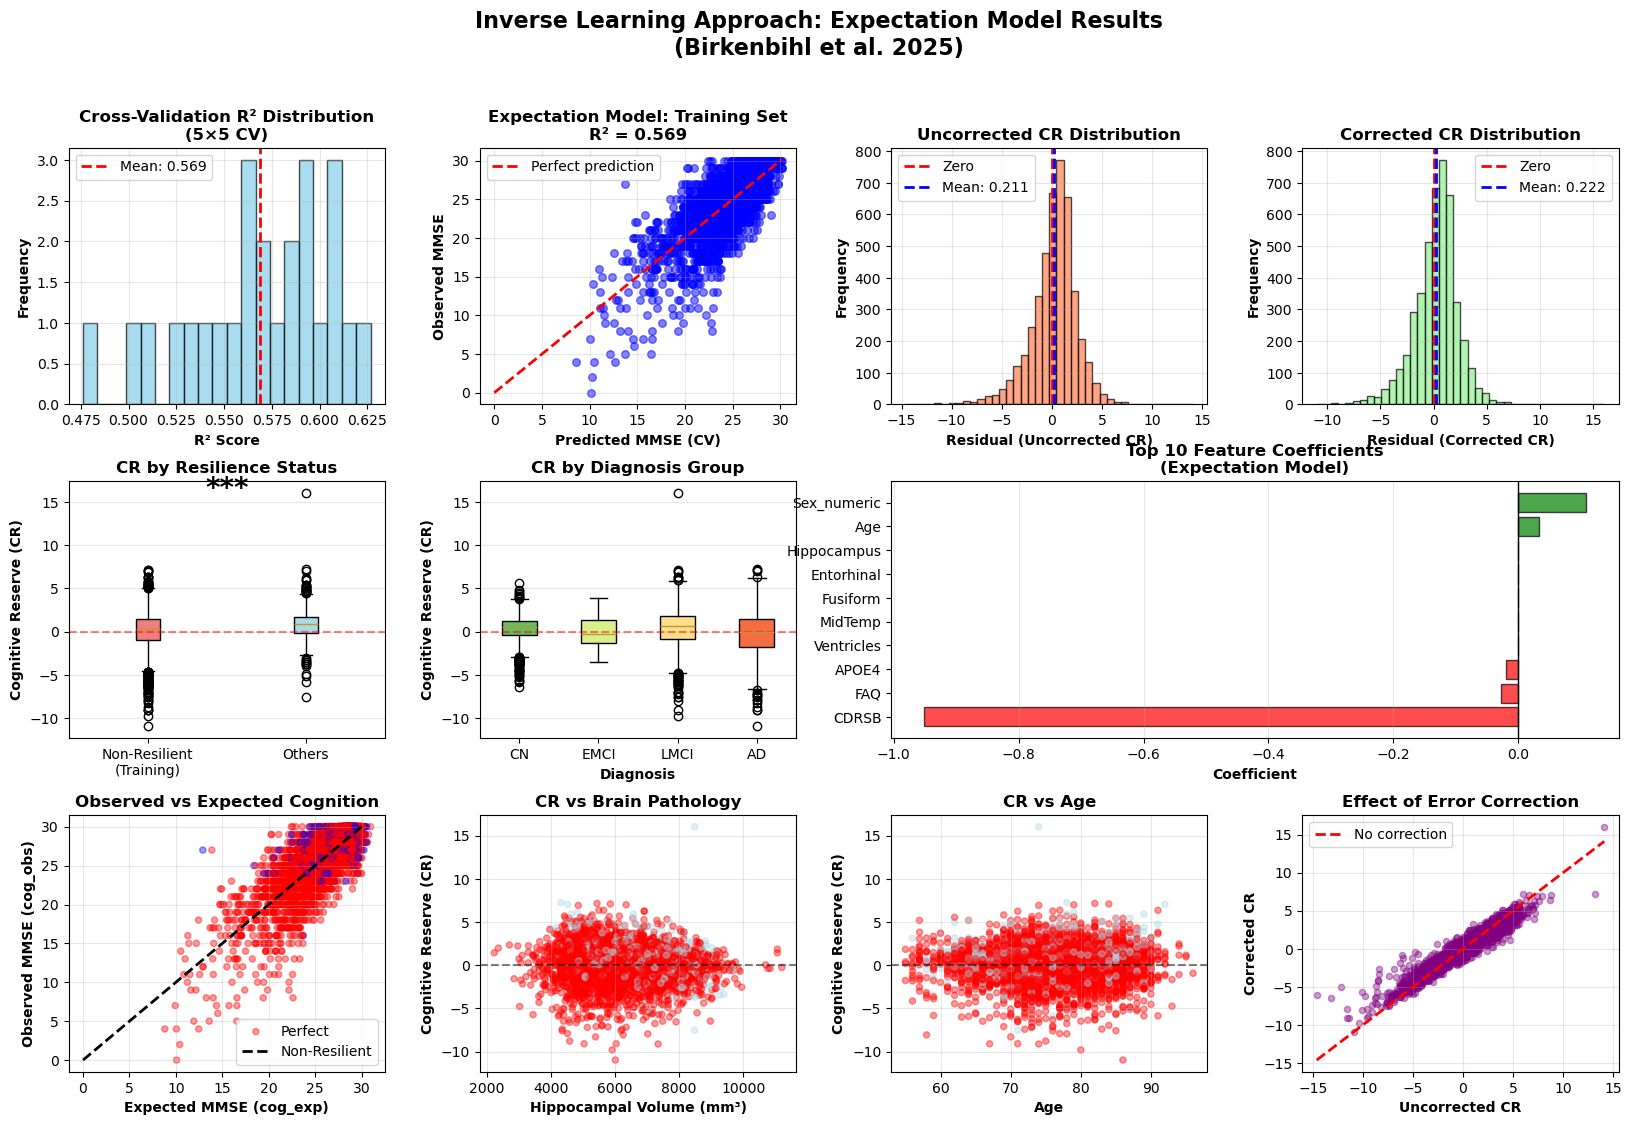


📊 Final Summary:
   - Total observations with CR estimates: 4,629
   - Unique subjects: 1,122
   - Expectation model CV R²: 0.569
   - Mean CR (corrected): 0.222
   - Non-resilient mean CR: 0.123 (should be ≈ 0)
   - Others mean CR: 0.856 (should be > 0)

✅ Cell 4 Complete!

Next Steps:
1. Analyze CR associations with outcomes (conversion, decline rate)
2. Test CR as moderator (pathology × CR interaction)
3. Compare with education-based CR proxy
4. Validate with external cohort
5. Investigate high-CR subjects (what makes them resilient?)



Exception ignored in: <function ResourceTracker.__del__ at 0x1046a5bc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x10305dbc0>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104f4dbc0>
Traceback (most recent call last

In [42]:
# 5.4 STEP 4: Calculate Cognitive Reserve (CR) Estimates

# STEP 4: CALCULATE FINAL CR ESTIMATES
# ============================================================================
print("\n" + "="*80)
print("STEP 4: Calculate Cognitive Reserve (CR) Estimates")
print("="*80)

print(f"""
Formula (from Birkenbihl et al. 2025):
  CR = cog_obs - cog_pred(Mnr) - error(Mer)
     = observed MMSE - expected MMSE - predicted error
""")

# Add to dataframe
df_all_clean['cog_obs'] = y_all_observed
df_all_clean['cog_exp'] = cog_exp
df_all_clean['predicted_error'] = predicted_errors_all
df_all_clean['CR_uncorrected'] = residuals_uncorrected
df_all_clean['CR_corrected'] = residuals_corrected

print(f"\n📊 CR Estimates Summary:")
print(f"\n  Uncorrected CR (without error correction):")
print(f"    Mean: {residuals_uncorrected.mean():.3f}")
print(f"    Std:  {residuals_uncorrected.std():.3f}")
print(f"    Range: [{residuals_uncorrected.min():.2f}, {residuals_uncorrected.max():.2f}]")

print(f"\n  Corrected CR (with error correction):")
print(f"    Mean: {residuals_corrected.mean():.3f}")
print(f"    Std:  {residuals_corrected.std():.3f}")
print(f"    Range: [{residuals_corrected.min():.2f}, {residuals_corrected.max():.2f}]")

difference = residuals_corrected.std() - residuals_uncorrected.std()
print(f"\n  Effect of error correction:")
print(f"    Δ Std: {difference:.3f} ({difference/residuals_uncorrected.std()*100:+.1f}%)")

# ============================================================================
# VALIDATION: Check Non-Resilient vs Others
# ============================================================================
print("\n" + "="*80)
print("VALIDATION: Non-Resilient vs Resilient")
print("="*80)

# Merge back to get NonResilient flag
df_all_clean = df_all_clean.merge(
    df[['Subject', 'NonResilient_MultiCriteria']].drop_duplicates(),
    on='Subject', how='left'
)

# Calculate mean CR by group
nonres_mask = df_all_clean['NonResilient_MultiCriteria'] == True
cr_nonres = df_all_clean[nonres_mask]['CR_corrected']
cr_others = df_all_clean[~nonres_mask]['CR_corrected']

print(f"\n📊 CR by Resilience Status:")
print(f"\n  Non-Resilient (trained on these):")
print(f"    N: {len(cr_nonres):,}")
print(f"    Mean CR: {cr_nonres.mean():.3f}")
print(f"    Std CR:  {cr_nonres.std():.3f}")
print(f"    Expected: ≈0 (these define the 'expectation')")

print(f"\n  Others (not used in training):")
print(f"    N: {len(cr_others):,}")
print(f"    Mean CR: {cr_others.mean():.3f}")
print(f"    Std CR:  {cr_others.std():.3f}")
print(f"    Expected: >0 (if they have cognitive reserve)")

# Statistical test
from scipy import stats as scipy_stats
t_stat, p_value = scipy_stats.ttest_ind(cr_nonres, cr_others)
print(f"\n  Independent t-test:")
print(f"    t-statistic: {t_stat:.3f}")
print(f"    p-value: {p_value:.3e}")

if p_value < 0.001:
    print(f"    ✅ Highly significant difference (p < 0.001)")
elif p_value < 0.05:
    print(f"    ✓ Significant difference (p < 0.05)")
else:
    print(f"    ⚠️  No significant difference (p > 0.05)")

# Check by diagnosis
print(f"\n📊 CR by Diagnosis Group:")
for dx in ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']:
    if dx in df_all_clean['DX_bl'].values:
        dx_cr = df_all_clean[df_all_clean['DX_bl'] == dx]['CR_corrected']
        print(f"  {dx:5s}: Mean = {dx_cr.mean():>6.3f}, Std = {dx_cr.std():>6.3f}, N = {len(dx_cr):>4,}")

# ============================================================================
# VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("Visualizing Results")
print("="*80)

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)

# 1. CV Scores Distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(cv_scores_r2, bins=20, edgecolor='black', alpha=0.7, color='skyblue')
ax1.axvline(cv_scores_r2.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores_r2.mean():.3f}')
ax1.set_xlabel('R² Score', fontweight='bold')
ax1.set_ylabel('Frequency', fontweight='bold')
ax1.set_title('Cross-Validation R² Distribution\n(5×5 CV)', fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Predicted vs Observed (Training)
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(y_train_cv_pred, y_train, alpha=0.5, s=30, color='blue')
min_val = min(y_train.min(), y_train_cv_pred.min())
max_val = max(y_train.max(), y_train_cv_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')
ax2.set_xlabel('Predicted MMSE (CV)', fontweight='bold')
ax2.set_ylabel('Observed MMSE', fontweight='bold')
ax2.set_title(f'Expectation Model: Training Set\nR² = {cv_scores_r2.mean():.3f}', fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

# 3. Residuals Distribution (Uncorrected)
ax3 = fig.add_subplot(gs[0, 2])
ax3.hist(residuals_uncorrected, bins=40, edgecolor='black', alpha=0.7, color='coral')
ax3.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax3.axvline(residuals_uncorrected.mean(), color='blue', linestyle='--', linewidth=2, 
            label=f'Mean: {residuals_uncorrected.mean():.3f}')
ax3.set_xlabel('Residual (Uncorrected CR)', fontweight='bold')
ax3.set_ylabel('Frequency', fontweight='bold')
ax3.set_title('Uncorrected CR Distribution', fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# 4. Residuals Distribution (Corrected)
ax4 = fig.add_subplot(gs[0, 3])
ax4.hist(residuals_corrected, bins=40, edgecolor='black', alpha=0.7, color='lightgreen')
ax4.axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
ax4.axvline(residuals_corrected.mean(), color='blue', linestyle='--', linewidth=2,
            label=f'Mean: {residuals_corrected.mean():.3f}')
ax4.set_xlabel('Residual (Corrected CR)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Corrected CR Distribution', fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)

# 5. CR by Resilience Status
ax5 = fig.add_subplot(gs[1, 0])
bp = ax5.boxplot([cr_nonres.dropna(), cr_others.dropna()], 
                  labels=['Non-Resilient\n(Training)', 'Others'],
                  patch_artist=True)
bp['boxes'][0].set_facecolor('lightcoral')
bp['boxes'][1].set_facecolor('lightblue')
ax5.axhline(0, color='red', linestyle='--', alpha=0.5)
ax5.set_ylabel('Cognitive Reserve (CR)', fontweight='bold')
ax5.set_title('CR by Resilience Status', fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# Add significance
if p_value < 0.001:
    ax5.text(1.5, ax5.get_ylim()[1] * 0.9, '***', ha='center', fontsize=20, fontweight='bold')
elif p_value < 0.01:
    ax5.text(1.5, ax5.get_ylim()[1] * 0.9, '**', ha='center', fontsize=20, fontweight='bold')
elif p_value < 0.05:
    ax5.text(1.5, ax5.get_ylim()[1] * 0.9, '*', ha='center', fontsize=20, fontweight='bold')

# 6. CR by Diagnosis
ax6 = fig.add_subplot(gs[1, 1])
dx_order = ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']
dx_present = [dx for dx in dx_order if dx in df_all_clean['DX_bl'].values]
cr_by_dx = [df_all_clean[df_all_clean['DX_bl'] == dx]['CR_corrected'].dropna() for dx in dx_present]

bp2 = ax6.boxplot(cr_by_dx, labels=dx_present, patch_artist=True)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(dx_present)))
for patch, color in zip(bp2['boxes'], colors):
    patch.set_facecolor(color)
ax6.axhline(0, color='red', linestyle='--', alpha=0.5)
ax6.set_ylabel('Cognitive Reserve (CR)', fontweight='bold')
ax6.set_xlabel('Diagnosis', fontweight='bold')
ax6.set_title('CR by Diagnosis Group', fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# 7. Feature Importance (Coefficients)
ax7 = fig.add_subplot(gs[1, 2:])
coef_plot = coef_df.head(10).sort_values('Coefficient')
colors_coef = ['red' if x < 0 else 'green' for x in coef_plot['Coefficient']]
ax7.barh(coef_plot['Feature'], coef_plot['Coefficient'], color=colors_coef, alpha=0.7, edgecolor='black')
ax7.axvline(0, color='black', linestyle='-', linewidth=1)
ax7.set_xlabel('Coefficient', fontweight='bold')
ax7.set_title('Top 10 Feature Coefficients\n(Expectation Model)', fontweight='bold')
ax7.grid(axis='x', alpha=0.3)

# 8. Observed vs Expected (All subjects)
ax8 = fig.add_subplot(gs[2, 0])
colors_scatter = ['red' if x else 'blue' for x in df_all_clean['NonResilient_MultiCriteria']]
ax8.scatter(df_all_clean['cog_exp'], df_all_clean['cog_obs'], alpha=0.4, s=20, c=colors_scatter)
ax8.plot([df_all_clean['cog_obs'].min(), df_all_clean['cog_obs'].max()], 
         [df_all_clean['cog_obs'].min(), df_all_clean['cog_obs'].max()], 
         'k--', linewidth=2, label='Perfect prediction')
ax8.set_xlabel('Expected MMSE (cog_exp)', fontweight='bold')
ax8.set_ylabel('Observed MMSE (cog_obs)', fontweight='bold')
ax8.set_title('Observed vs Expected Cognition', fontweight='bold')
ax8.legend(['Perfect', 'Non-Resilient', 'Others'], loc='lower right')
ax8.grid(alpha=0.3)

# 9. CR vs Hippocampus
ax9 = fig.add_subplot(gs[2, 1])
df_plot = df_all_clean.dropna(subset=['Hippocampus', 'CR_corrected'])
colors_hippo = ['red' if x else 'lightblue' for x in df_plot['NonResilient_MultiCriteria']]
ax9.scatter(df_plot['Hippocampus'], df_plot['CR_corrected'], 
           alpha=0.4, s=20, c=colors_hippo)
ax9.axhline(0, color='black', linestyle='--', alpha=0.5)
ax9.set_xlabel('Hippocampal Volume (mm³)', fontweight='bold')
ax9.set_ylabel('Cognitive Reserve (CR)', fontweight='bold')
ax9.set_title('CR vs Brain Pathology', fontweight='bold')
ax9.grid(alpha=0.3)

# 10. CR vs Age
ax10 = fig.add_subplot(gs[2, 2])
df_plot_age = df_all_clean.dropna(subset=['Age', 'CR_corrected'])
colors_age = ['red' if x else 'lightblue' for x in df_plot_age['NonResilient_MultiCriteria']]
ax10.scatter(df_plot_age['Age'], df_plot_age['CR_corrected'],
            alpha=0.4, s=20, c=colors_age)
ax10.axhline(0, color='black', linestyle='--', alpha=0.5)
ax10.set_xlabel('Age', fontweight='bold')
ax10.set_ylabel('Cognitive Reserve (CR)', fontweight='bold')
ax10.set_title('CR vs Age', fontweight='bold')
ax10.grid(alpha=0.3)

# 11. Error Correction Effect
ax11 = fig.add_subplot(gs[2, 3])
ax11.scatter(df_all_clean['CR_uncorrected'], df_all_clean['CR_corrected'], alpha=0.4, s=20, color='purple')
ax11.plot([df_all_clean['CR_uncorrected'].min(), df_all_clean['CR_uncorrected'].max()],
         [df_all_clean['CR_uncorrected'].min(), df_all_clean['CR_uncorrected'].max()],
         'r--', linewidth=2, label='No correction')
ax11.set_xlabel('Uncorrected CR', fontweight='bold')
ax11.set_ylabel('Corrected CR', fontweight='bold')
ax11.set_title('Effect of Error Correction', fontweight='bold')
ax11.legend()
ax11.grid(alpha=0.3)

plt.suptitle('Inverse Learning Approach: Expectation Model Results\n(Birkenbihl et al. 2025)', 
             fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Summary statistics
print(f"\n📊 Final Summary:")
print(f"   - Total observations with CR estimates: {len(df_all_clean):,}")
print(f"   - Unique subjects: {df_all_clean['Subject'].nunique():,}")
print(f"   - Expectation model CV R²: {cv_scores_r2.mean():.3f}")
print(f"   - Mean CR (corrected): {residuals_corrected.mean():.3f}")
print(f"   - Non-resilient mean CR: {cr_nonres.mean():.3f} (should be ≈ 0)")
print(f"   - Others mean CR: {cr_others.mean():.3f} (should be > 0)")

print("\n" + "="*80)
print("✅ Cell 4 Complete!")
print("="*80)
print("""
Next Steps:
1. Analyze CR associations with outcomes (conversion, decline rate)
2. Test CR as moderator (pathology × CR interaction)
3. Compare with education-based CR proxy
4. Validate with external cohort
5. Investigate high-CR subjects (what makes them resilient?)
""")